# 1. Обработка данных

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


F1 = "F107_1947_1996.txt"
F2 = "F107_1996_2007.txt"
F3 = "fluxtable.txt"

HARD_OUTLIER_LIMIT = 500

plots_dir = Path("f107_plots")
plots_dir.mkdir(exist_ok=True)


# вспомогательные функции


def read_rows(path, sep, n_cols):
    # читает только строки с данными, пропуская заголовки и служебный текст
    rows = []

    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            line = line.strip().strip('"')

            if not line or not line[0].isdigit():
                continue

            parts = line.split(",") if sep == "," else line.split()
            parts = [x.strip() for x in parts]

            if len(parts) >= n_cols:
                rows.append(parts[:n_cols])

    return rows


def to_num(s):
    return pd.to_numeric(s, errors="coerce")


def clean_flux(s):
    return to_num(s).replace(0, np.nan)


def make_date(df):
    return pd.to_datetime(
        {
            "year": to_num(df["year"]),
            "month": to_num(df["month"]),
            "day": to_num(df["day"])
        },
        errors="coerce"
    )


def normalize_time(s, width):
    return (
        s.astype(str)
        .str.replace(r"\.0$", "", regex=True)
        .str.zfill(width)
    )


def make_datetime(date, time, with_seconds=False):
    if with_seconds:
        time_str = time.str[:2] + ":" + time.str[2:4] + ":" + time.str[4:6]
    else:
        time_str = time.str[:2] + ":" + time.str[2:4]

    return pd.to_datetime(date.astype(str) + " " + time_str, errors="coerce")


def finish_flux_table(df, source):
    # приводит таблицу из любого архива к единому формату
    df["source"] = source
    df["julian_date"] = to_num(df["julian_date"])
    df["carrington_rotation"] = to_num(df["carrington_rotation"])

    for col in ["f107_obs", "f107_adj", "f107_ursi"]:
        df[col] = clean_flux(df[col])

    cols = [
        "date", "time", "datetime",
        "julian_date", "carrington_rotation",
        "f107_obs", "f107_adj", "f107_ursi",
        "source"
    ]

    return df[cols]


# чтение трёх архивов

def read_1947_1996(path):
    df = pd.DataFrame(
        read_rows(path, sep=",", n_cols=8),
        columns=[
            "julian_date", "carrington_rotation",
            "year", "month", "day",
            "f107_obs", "f107_adj", "f107_ursi"
        ]
    )

    df["date"] = make_date(df)
    df["time"] = pd.NA
    df["datetime"] = df["date"]

    return finish_flux_table(df, "F107_1947_1996")


def read_1996_2007(path):
    df = pd.DataFrame(
        read_rows(path, sep="space", n_cols=9),
        columns=[
            "julian_date", "carrington_rotation",
            "year", "month", "day", "time",
            "f107_obs", "f107_adj", "f107_ursi"
        ]
    )

    df["date"] = make_date(df)
    df["time"] = normalize_time(df["time"], 4)
    df["datetime"] = make_datetime(df["date"], df["time"])

    return finish_flux_table(df, "F107_1996_2007")


def read_fluxtable(path):
    df = pd.DataFrame(
        read_rows(path, sep="space", n_cols=7),
        columns=[
            "fluxdate", "time",
            "julian_date", "carrington_rotation",
            "f107_obs", "f107_adj", "f107_ursi"
        ]
    )

    df["date"] = pd.to_datetime(df["fluxdate"], format="%Y%m%d", errors="coerce")
    df["time"] = normalize_time(df["time"], 6)
    df["datetime"] = make_datetime(df["date"], df["time"], with_seconds=True)

    return finish_flux_table(df, "fluxtable")


df1 = read_1947_1996(F1)
df2 = read_1996_2007(F2)
df3 = read_fluxtable(F3)

for name, df in [("F1", df1), ("F2", df2), ("F3", df3)]:
    print(name, df.shape, df["date"].min(), "-", df["date"].max())


# объединение источников без пересечения периодов

cut_1996 = df2["date"].min()
cut_2004 = df3["date"].min()

df_obs = pd.concat(
    [
        df1[df1["date"] < cut_1996],
        df2[(df2["date"] >= cut_1996) & (df2["date"] < cut_2004)],
        df3[df3["date"] >= cut_2004]
    ],
    ignore_index=True
)

df_obs = (
    df_obs
    .dropna(subset=["date", "f107_adj"])
    .sort_values(["date", "datetime"])
    .reset_index(drop=True)
)

df_before_outliers = df_obs.copy()
df_before_outliers.to_csv(
    "f107_observations_combined_before_outlier_filter.csv",
    index=False
)


# фильтр грубых выбросов

outlier_mask = (
    (df_obs["f107_obs"] > HARD_OUTLIER_LIMIT) |
    (df_obs["f107_adj"] > HARD_OUTLIER_LIMIT)
)

df_removed_outliers = df_obs[outlier_mask].copy()
df_removed_outliers.to_csv("f107_removed_outliers.csv", index=False)

df_obs = df_obs[~outlier_mask].reset_index(drop=True)
df_obs.to_csv("f107_observations_combined_clean.csv", index=False)


# дневная агрегация

df_daily = (
    df_obs
    .groupby("date", as_index=False)
    .agg(
        f107_obs=("f107_obs", "median"),
        f107_adj=("f107_adj", "median"),
        f107_ursi=("f107_ursi", "median"),
        julian_date=("julian_date", "mean"),
        carrington_rotation=("carrington_rotation", "mean"),
        n_measurements=("f107_adj", "count"),
        source=("source", lambda x: ";".join(sorted(set(x))))
    )
)

df_daily.to_csv("f107_daily_combined.csv", index=False)


# полная дневная сетка с пропусками

full_dates = pd.date_range(
    df_daily["date"].min(),
    df_daily["date"].max(),
    freq="D"
)

df_daily_full = (
    df_daily
    .set_index("date")
    .reindex(full_dates)
    .rename_axis("date")
    .reset_index()
)

df_daily_full["is_missing_original"] = df_daily_full["f107_adj"].isna()
df_daily_full["data_status"] = np.where(
    df_daily_full["is_missing_original"],
    "missing",
    "observed"
)

df_daily_full["n_measurements"] = (
    df_daily_full["n_measurements"]
    .fillna(0)
    .astype(int)
)

df_daily_full["source"] = df_daily_full["source"].fillna("missing")

df_daily_full.to_csv("f107_daily_full_with_gaps.csv", index=False)


# месячная агрегация

df_monthly = (
    df_daily
    .set_index("date")
    .resample("ME")
    .agg(
        f107_obs=("f107_obs", "mean"),
        f107_adj=("f107_adj", "mean"),
        f107_ursi=("f107_ursi", "mean"),
        n_days=("f107_adj", "count"),
        n_measurements=("n_measurements", "sum")
    )
    .dropna(subset=["f107_adj"])
    .reset_index()
)

df_monthly.to_csv("f107_monthly_combined.csv", index=False)


# месячная таблица с информацией о пропусках
df_monthly_full_info = (
    df_daily_full
    .set_index("date")
    .resample("ME")
    .agg(
        f107_obs=("f107_obs", "mean"),
        f107_adj=("f107_adj", "mean"),
        f107_ursi=("f107_ursi", "mean"),
        n_calendar_days=("data_status", "count"),
        n_observed_days=("is_missing_original", lambda x: (~x).sum()),
        n_missing_days=("is_missing_original", "sum"),
        n_measurements=("n_measurements", "sum")
    )
    .reset_index()
)

df_monthly_full_info.to_csv("f107_monthly_full_info.csv", index=False)


# проверка результата

saved_files = [
    "f107_observations_combined_before_outlier_filter.csv",
    "f107_removed_outliers.csv",
    "f107_observations_combined_clean.csv",
    "f107_daily_combined.csv",
    "f107_daily_full_with_gaps.csv",
    "f107_monthly_combined.csv",
    "f107_monthly_full_info.csv"
]

print("\nCombined before outlier filter:", df_before_outliers.shape)
print("Removed outliers:", len(df_removed_outliers))
print("Clean observations:", df_obs.shape)
print("Daily observed:", df_daily.shape)
print("Daily full with gaps:", df_daily_full.shape)
print("Monthly:", df_monthly.shape)
print("Monthly full info:", df_monthly_full_info.shape)

print("\nDate range:")
print(df_daily_full["date"].min(), "-", df_daily_full["date"].max())

print("\nMissing days:")
print(df_daily_full["is_missing_original"].sum())

print("\nDays with more than one measurement:")
print((df_daily["n_measurements"] > 1).sum())

print("\nMax values after cleaning:")
display(df_obs[["f107_obs", "f107_adj", "f107_ursi"]].max().to_frame("max"))

print("\nSaved files:")
for file in saved_files:
    print(file)

F1 (17987, 9) 1947-01-01 00:00:00 - 1996-03-31 00:00:00
F2 (12378, 9) 1996-02-14 00:00:00 - 2007-06-18 00:00:00
F3 (23555, 9) 2004-10-28 00:00:00 - 2026-05-08 00:00:00

Combined before outlier filter: (50338, 9)
Removed outliers: 15
Clean observations: (50323, 9)
Daily observed: (28289, 8)
Daily full with gaps: (28939, 10)
Monthly: (952, 6)
Monthly full info: (952, 8)

Date range:
1947-02-14 00:00:00 - 2026-05-08 00:00:00

Missing days:
650

Days with more than one measurement:
11022

Max values after cleaning:


,max
f107_obs,468.0
f107_adj,478.4
f107_ursi,430.6



Saved files:
f107_observations_combined_before_outlier_filter.csv
f107_removed_outliers.csv
f107_observations_combined_clean.csv
f107_daily_combined.csv
f107_daily_full_with_gaps.csv
f107_monthly_combined.csv
f107_monthly_full_info.csv


In [2]:
files = [
    "f107_observations_combined_before_outlier_filter.csv",
    "f107_removed_outliers.csv",
    "f107_observations_combined_clean.csv",
    "f107_daily_combined.csv",
    "f107_daily_full_with_gaps.csv",
    "f107_monthly_combined.csv",
    "f107_monthly_full_info.csv"
]

flux_cols = ["f107_obs", "f107_adj", "f107_ursi"]
int_cols = [
    "n_measurements",
    "n_days",
    "n_calendar_days",
    "n_observed_days",
    "n_missing_days"
]


# приводим сохранённые таблицы к точности исходных файлов

for file in files:
    path = Path(file)

    if not path.exists():
        print("File not found:", file)
        continue

    df = pd.read_csv(path)

    for col in flux_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce").round(1)

    if "julian_date" in df.columns:
        df["julian_date"] = pd.to_numeric(
            df["julian_date"],
            errors="coerce"
        ).round(3)

    if "carrington_rotation" in df.columns:
        df["carrington_rotation"] = pd.to_numeric(
            df["carrington_rotation"],
            errors="coerce"
        ).round(4)

    for col in int_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce").astype("Int64")

    df.to_csv(path, index=False)

In [3]:
plots_dir = Path("f107_plots")
plots_dir.mkdir(exist_ok=True)


# загружаем подготовленные CSV после очистки и округления

tables = {
    "before_outlier_filter": (
        "f107_observations_combined_before_outlier_filter.csv",
        ["date", "datetime"]
    ),
    "removed_outliers": (
        "f107_removed_outliers.csv",
        ["date", "datetime"]
    ),
    "clean_observations": (
        "f107_observations_combined_clean.csv",
        ["date", "datetime"]
    ),
    "daily": (
        "f107_daily_combined.csv",
        ["date"]
    ),
    "daily_full": (
        "f107_daily_full_with_gaps.csv",
        ["date"]
    ),
    "monthly": (
        "f107_monthly_combined.csv",
        ["date"]
    ),
    "monthly_info": (
        "f107_monthly_full_info.csv",
        ["date"]
    )
}

loaded = {}

for name, (file, date_cols) in tables.items():
    loaded[name] = pd.read_csv(file, parse_dates=date_cols)


df_before_outlier_filter = loaded["before_outlier_filter"]
df_removed_outliers = loaded["removed_outliers"]
df_raw = loaded["clean_observations"]
df_daily = loaded["daily"]
df_daily_full = loaded["daily_full"]
df_monthly = loaded["monthly"]
df_monthly_info = loaded["monthly_info"]

In [4]:
# годовая агрегация и оценка пропусков

df_yearly = df_daily_full.copy()
df_yearly["year"] = df_yearly["date"].dt.year

df_yearly = (
    df_yearly
    .groupby("year", as_index=False)
    .agg(
        f107_obs=("f107_obs", "mean"),
        f107_adj=("f107_adj", "mean"),
        f107_ursi=("f107_ursi", "mean"),
        observed_days=("is_missing_original", lambda x: (~x).sum()),
        missing_days=("is_missing_original", "sum"),
        total_measurements=("n_measurements", "sum")
    )
)

df_yearly["missing_share"] = (
    df_yearly["missing_days"] /
    (df_yearly["observed_days"] + df_yearly["missing_days"])
).round(3)

df_yearly[["f107_obs", "f107_adj", "f107_ursi"]] = (
    df_yearly[["f107_obs", "f107_adj", "f107_ursi"]]
    .round(1)
)

df_yearly.to_csv("f107_yearly_combined.csv", index=False)

display(df_yearly.head())
display(df_yearly.tail())

,year,f107_obs,f107_adj,f107_ursi,observed_days,missing_days,total_measurements,missing_share
0,1947,219.1,220.6,198.5,260,61,260,0.190
1,1948,174.7,175.1,157.6,320,46,320,0.126
2,1949,177.7,177.6,159.9,320,45,320,0.123
3,1950,128.2,128.2,115.4,267,98,267,0.268
4,1951,119.4,119.7,107.7,274,91,274,0.249


,year,f107_obs,f107_adj,f107_ursi,observed_days,missing_days,total_measurements,missing_share
75,2022,124.3,124.3,111.9,365,0,1101,0.0
76,2023,158.5,158.6,142.7,365,0,1099,0.0
77,2024,190.2,190.5,171.4,366,0,1098,0.0
78,2025,154.2,154.0,138.6,365,0,1092,0.0
79,2026,134.3,132.4,119.2,128,0,384,0.0


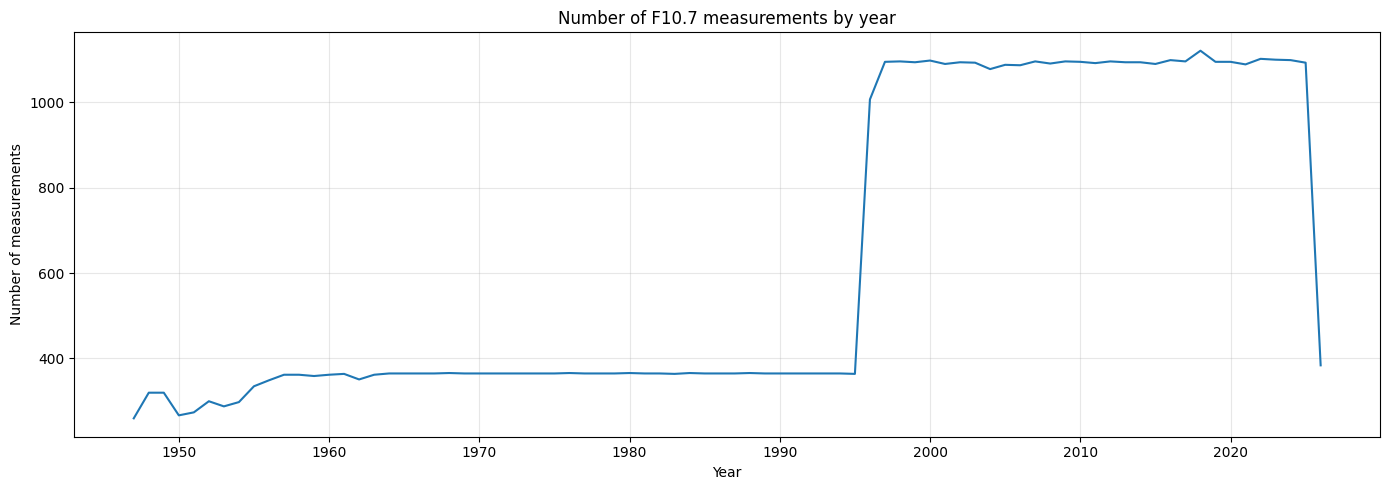

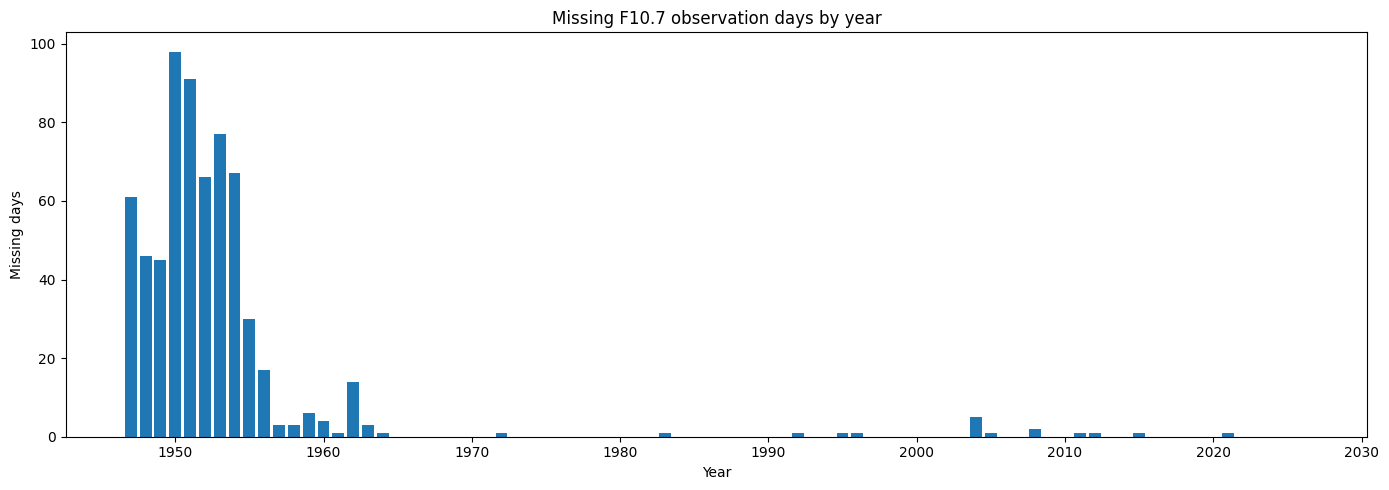

In [5]:
# количество измерений по годам

plt.figure(figsize=(14, 5))

plt.plot(
    df_yearly["year"],
    df_yearly["total_measurements"],
    linewidth=1.5
)

plt.title("Number of F10.7 measurements by year")
plt.xlabel("Year")
plt.ylabel("Number of measurements")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(plots_dir / "01_measurements_by_year.png", dpi=150)
plt.show()


# количество пропущенных дней по годам

plt.figure(figsize=(14, 5))

plt.bar(
    df_yearly["year"],
    df_yearly["missing_days"]
)

plt.title("Missing F10.7 observation days by year")
plt.xlabel("Year")
plt.ylabel("Missing days")

plt.tight_layout()
plt.savefig(plots_dir / "02_missing_days_by_year.png", dpi=150)
plt.show()

# 2. Первичная визуализация

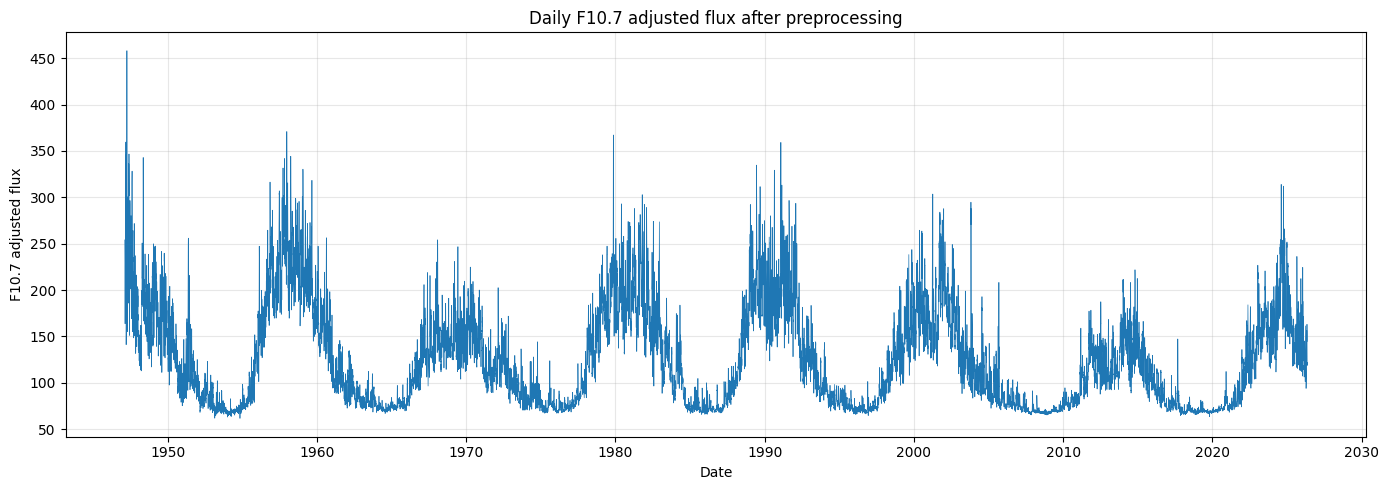

In [6]:
# дневной ряд после очистки и объединения источников

plt.figure(figsize=(14, 5))

plt.plot(
    df_daily["date"],
    df_daily["f107_adj"],
    linewidth=0.5
)

plt.title("Daily F10.7 adjusted flux after preprocessing")
plt.xlabel("Date")
plt.ylabel("F10.7 adjusted flux")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(plots_dir / "03_daily_f107_adj_preprocessed.png", dpi=150)
plt.show()

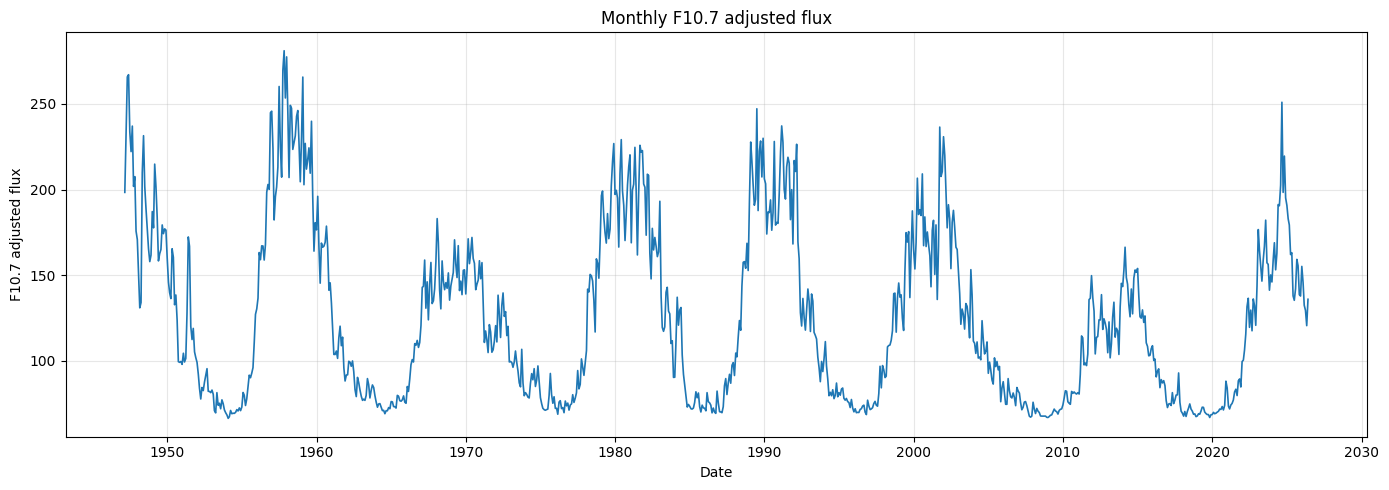

In [7]:
# месячный ряд, показывающий долгосрочную циклическую структуру

plt.figure(figsize=(14, 5))

plt.plot(
    df_monthly["date"],
    df_monthly["f107_adj"],
    linewidth=1.2
)

plt.title("Monthly F10.7 adjusted flux")
plt.xlabel("Date")
plt.ylabel("F10.7 adjusted flux")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(plots_dir / "04_monthly_f107_adj.png", dpi=150)
plt.show()

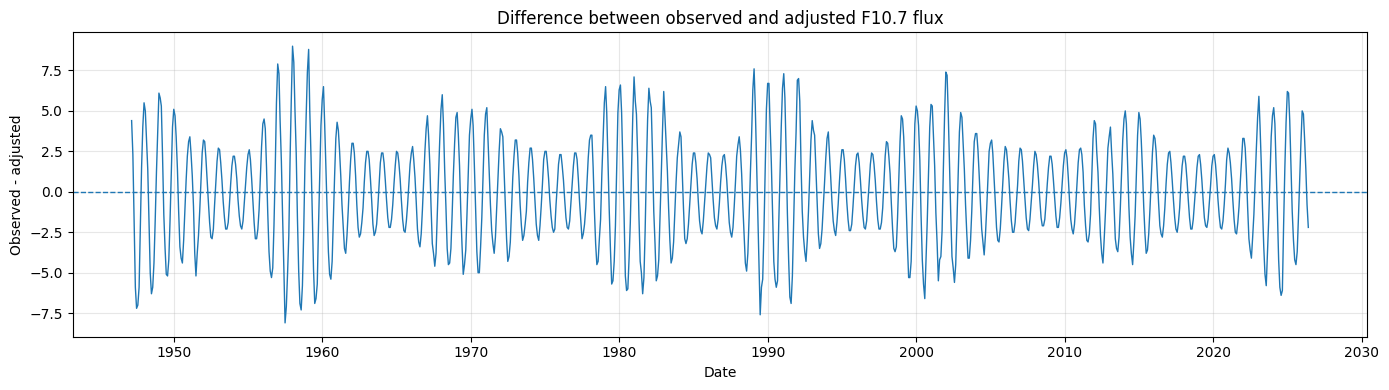

In [8]:
# разница между observed и adjusted

diff_obs_adj = df_monthly["f107_obs"] - df_monthly["f107_adj"]

plt.figure(figsize=(14, 4))

plt.plot(
    df_monthly["date"],
    diff_obs_adj,
    linewidth=1
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.title("Difference between observed and adjusted F10.7 flux")
plt.xlabel("Date")
plt.ylabel("Observed - adjusted")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(plots_dir / "05_monthly_f107_observed_adjusted_difference.png", dpi=150)
plt.show()

In [9]:
df_monthly[["f107_obs", "f107_adj", "f107_ursi"]].corr().round(3)

,f107_obs,f107_adj,f107_ursi
f107_obs,1.000,0.998,0.998
f107_adj,0.998,1.000,1.000
f107_ursi,0.998,1.000,1.000


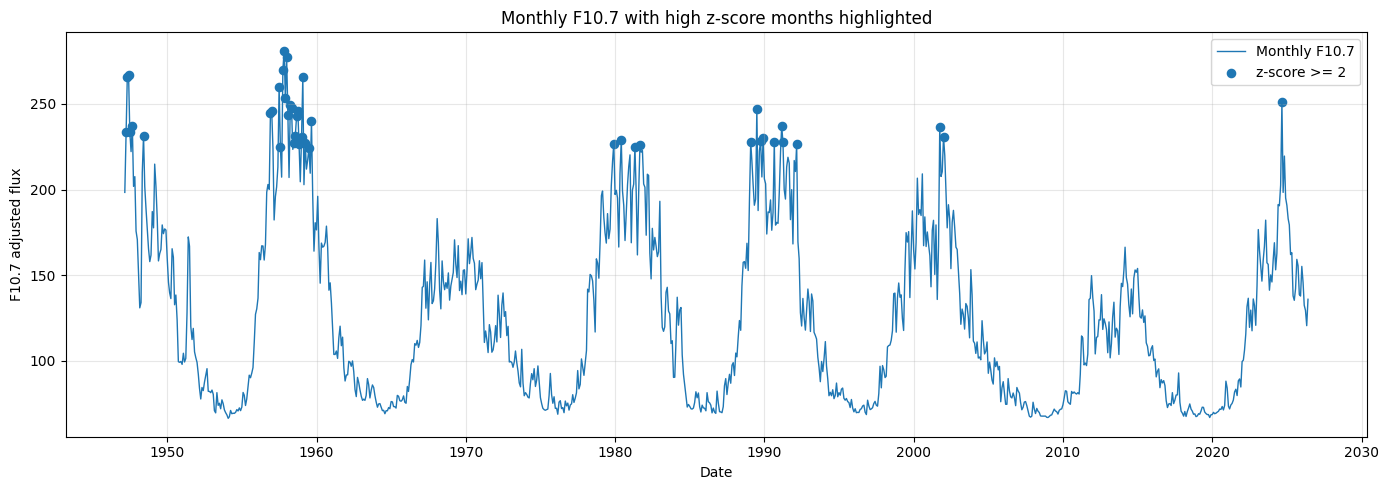

In [10]:
# выделяем месяцы с необычно высокой солнечной активностью

df_top_activity = df_monthly.copy()

mean_f107 = df_top_activity["f107_adj"].mean()
std_f107 = df_top_activity["f107_adj"].std()

df_top_activity["z_score"] = (
    df_top_activity["f107_adj"] - mean_f107
) / std_f107

high_z = df_top_activity["z_score"] >= 2


plt.figure(figsize=(14, 5))

plt.plot(
    df_top_activity["date"],
    df_top_activity["f107_adj"],
    linewidth=1,
    label="Monthly F10.7"
)

plt.scatter(
    df_top_activity.loc[high_z, "date"],
    df_top_activity.loc[high_z, "f107_adj"],
    s=35,
    label="z-score >= 2"
)

plt.title("Monthly F10.7 with high z-score months highlighted")
plt.xlabel("Date")
plt.ylabel("F10.7 adjusted flux")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.savefig(plots_dir / "06_top_activity_zscore_timeline.png", dpi=150)
plt.show()

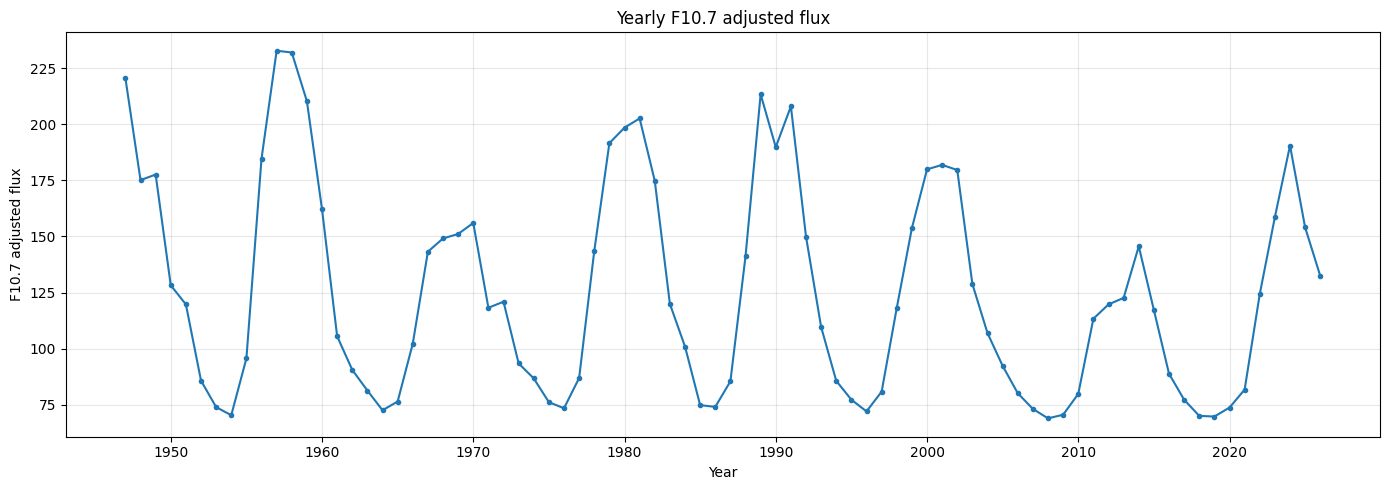

In [11]:
# годовая динамика F10.7

plt.figure(figsize=(14, 5))

plt.plot(
    df_yearly["year"],
    df_yearly["f107_adj"],
    linewidth=1.5,
    marker="o",
    markersize=3
)

plt.title("Yearly F10.7 adjusted flux")
plt.xlabel("Year")
plt.ylabel("F10.7 adjusted flux")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(plots_dir / "07_yearly_f107_adj.png", dpi=150)
plt.show()

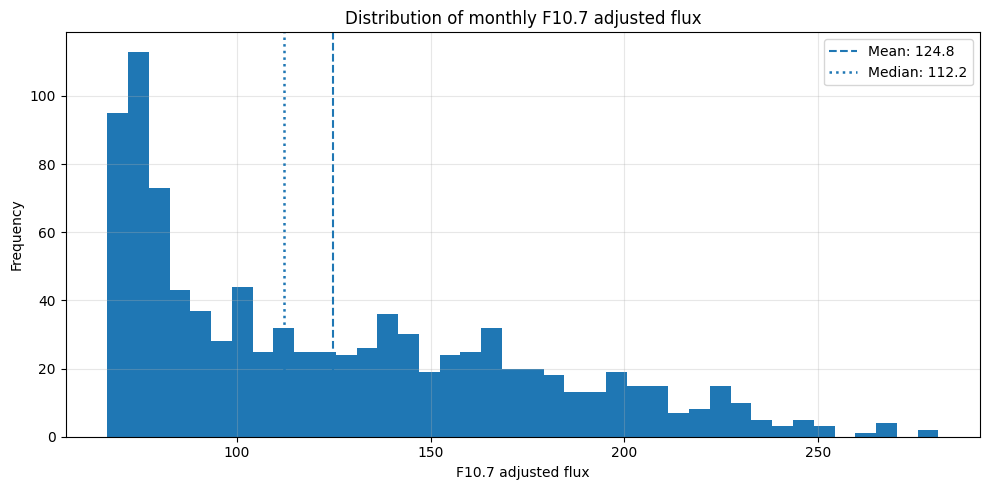

In [12]:
# распределение месячных значений F10.7

monthly_f107 = df_monthly["f107_adj"].dropna()

mean_value = monthly_f107.mean()
median_value = monthly_f107.median()

plt.figure(figsize=(10, 5))

plt.hist(
    monthly_f107,
    bins=40
)

plt.axvline(
    mean_value,
    linestyle="--",
    linewidth=1.5,
    label=f"Mean: {mean_value:.1f}"
)

plt.axvline(
    median_value,
    linestyle=":",
    linewidth=1.8,
    label=f"Median: {median_value:.1f}"
)

plt.title("Distribution of monthly F10.7 adjusted flux")
plt.xlabel("F10.7 adjusted flux")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.savefig(plots_dir / "08_distribution_monthly_f107_adj.png", dpi=150)
plt.show()

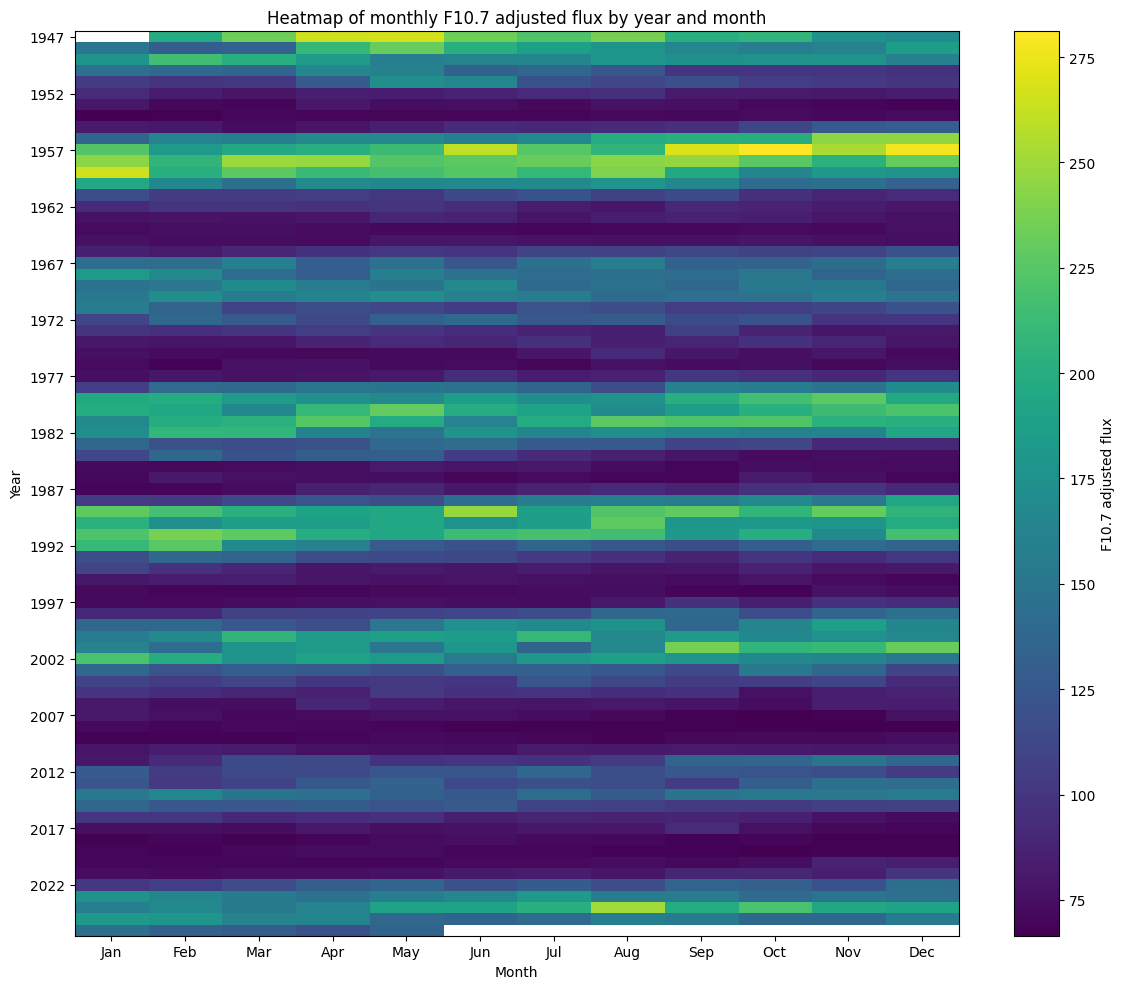

In [13]:
# тепловая карта: годы по вертикали, месяцы по горизонтали

heatmap_df = df_monthly.copy()

heatmap_df["year"] = heatmap_df["date"].dt.year
heatmap_df["month"] = heatmap_df["date"].dt.month

heatmap = heatmap_df.pivot(
    index="year",
    columns="month",
    values="f107_adj"
)

month_names = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]


plt.figure(figsize=(12, 10))

plt.imshow(
    heatmap,
    aspect="auto"
)

plt.colorbar(label="F10.7 adjusted flux")

plt.title("Heatmap of monthly F10.7 adjusted flux by year and month")
plt.xlabel("Month")
plt.ylabel("Year")

plt.xticks(
    range(12),
    month_names
)

year_step = 5

plt.yticks(
    range(0, len(heatmap.index), year_step),
    heatmap.index[::year_step]
)

plt.tight_layout()
plt.savefig(plots_dir / "09_monthly_f107_heatmap.png", dpi=150)
plt.show()

# 3. Сглаживание, режимы активности и волатильность

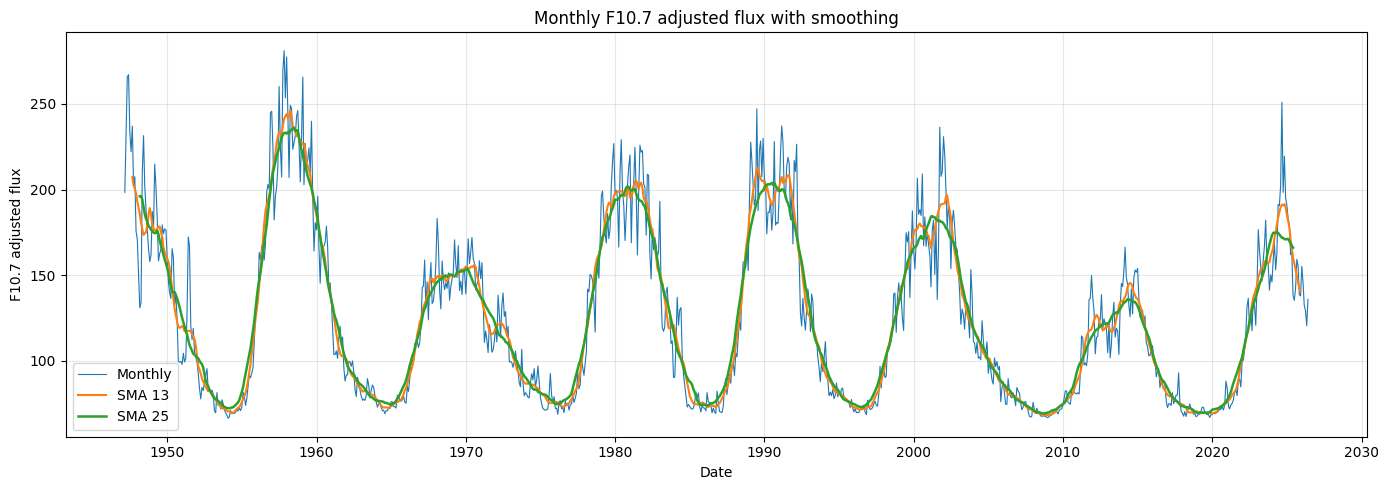

In [14]:
# сглаживание месячного ряда:
# SMA 13 - для общей формы и режимов,
# SMA 25 - для более устойчивого выделения циклов

df_monthly_smooth = df_monthly.copy()

df_monthly_smooth["sma_13"] = (
    df_monthly_smooth["f107_adj"]
    .rolling(window=13, center=True)
    .mean()
)

df_monthly_smooth["sma_25"] = (
    df_monthly_smooth["f107_adj"]
    .rolling(window=25, center=True)
    .mean()
)


plt.figure(figsize=(14, 5))

plt.plot(
    df_monthly_smooth["date"],
    df_monthly_smooth["f107_adj"],
    linewidth=0.8,
    label="Monthly"
)

plt.plot(
    df_monthly_smooth["date"],
    df_monthly_smooth["sma_13"],
    linewidth=1.5,
    label="SMA 13"
)

plt.plot(
    df_monthly_smooth["date"],
    df_monthly_smooth["sma_25"],
    linewidth=1.8,
    label="SMA 25"
)

plt.title("Monthly F10.7 adjusted flux with smoothing")
plt.xlabel("Date")
plt.ylabel("F10.7 adjusted flux")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.savefig(plots_dir / "10_monthly_f107_adj_smoothing.png", dpi=150)
plt.show()

Cycle states:


,months
cycle_state,
plateau,325
falling,324
rising,273


Activity levels:


,months
activity_level,
low,310
medium,308
high,304


Volatility states:


,months
volatility_state,
normal,696
high,226


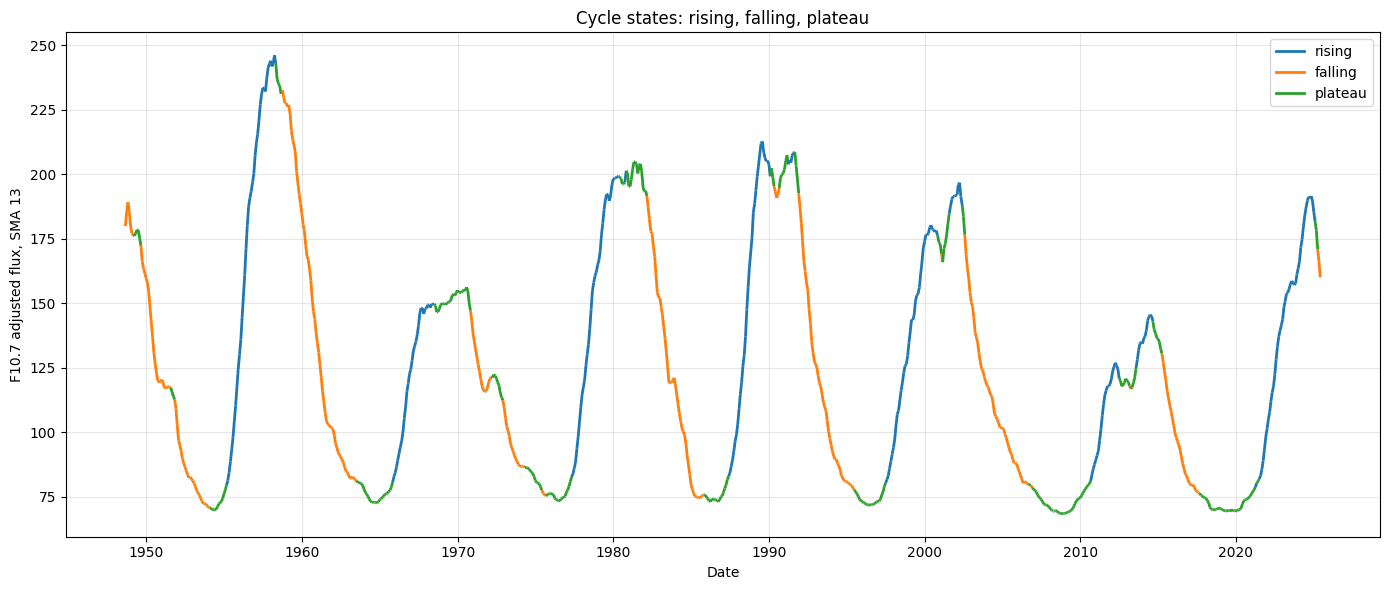

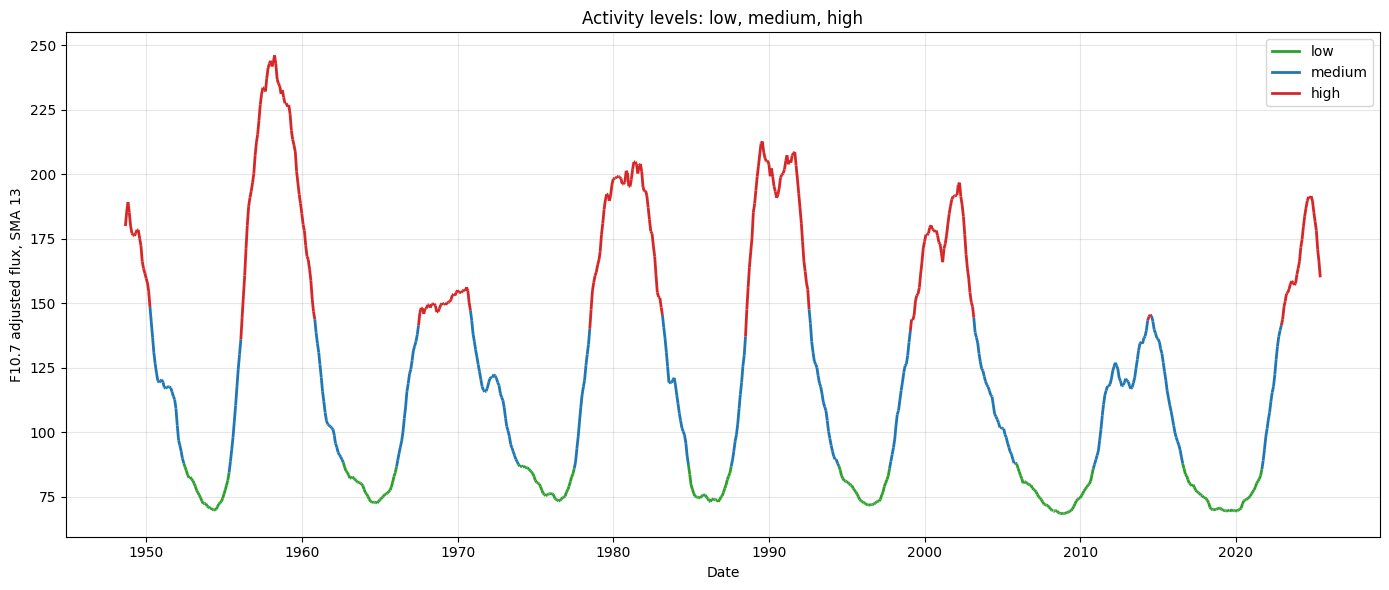

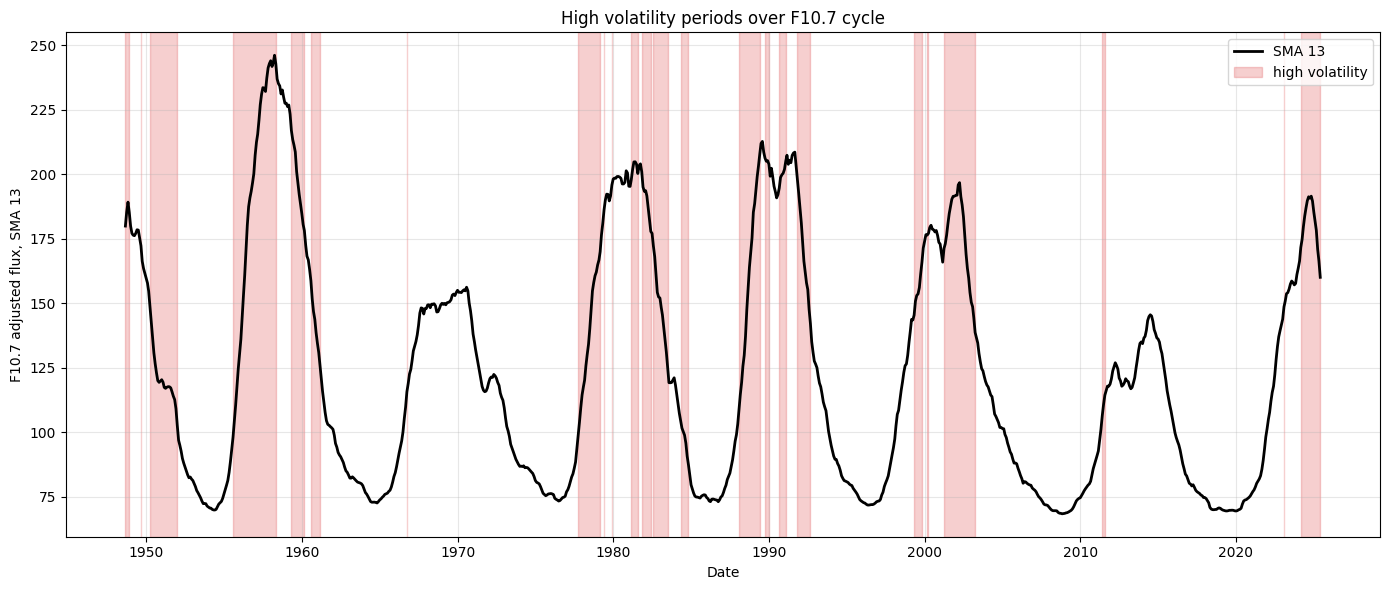

In [15]:
# режимная структура F10.7: фазы цикла, уровни активности и волатильность

from matplotlib.collections import LineCollection
from matplotlib.lines import Line2D
import matplotlib.dates as mdates


SLOPE_MONTHS = 12
VOL_WINDOW = 13

PLATEAU_Q = 0.35
LOW_ACTIVITY_Q = 0.33
HIGH_ACTIVITY_Q = 0.66
HIGH_VOL_Q = 0.75


df_regime = (
    df_monthly_smooth[["date", "f107_adj", "sma_13"]]
    .dropna(subset=["sma_13"])
    .reset_index(drop=True)
)


# фазы цикла по наклону SMA 13 за 12 месяцев

df_regime["slope_12m"] = (
    df_regime["sma_13"] - df_regime["sma_13"].shift(SLOPE_MONTHS)
) / SLOPE_MONTHS

slope_limit = df_regime["slope_12m"].abs().quantile(PLATEAU_Q)

df_regime["cycle_state"] = np.select(
    [
        df_regime["slope_12m"] > slope_limit,
        df_regime["slope_12m"] < -slope_limit
    ],
    [
        "rising",
        "falling"
    ],
    default="plateau"
)


# уровни активности по квантилям SMA 13

low_limit = df_regime["sma_13"].quantile(LOW_ACTIVITY_Q)
high_limit = df_regime["sma_13"].quantile(HIGH_ACTIVITY_Q)

df_regime["activity_level"] = np.select(
    [
        df_regime["sma_13"] < low_limit,
        df_regime["sma_13"] > high_limit
    ],
    [
        "low",
        "high"
    ],
    default="medium"
)


# волатильность как скользящее стандартное отклонение

df_regime["volatility_13m"] = (
    df_regime["f107_adj"]
    .rolling(window=VOL_WINDOW, center=True)
    .std()
)

vol_limit = df_regime["volatility_13m"].quantile(HIGH_VOL_Q)

df_regime["volatility_state"] = np.where(
    df_regime["volatility_13m"] > vol_limit,
    "high",
    "normal"
)


df_regime = (
    df_regime
    .dropna(subset=["slope_12m", "volatility_13m"])
    .reset_index(drop=True)
)

df_regime.to_csv("f107_monthly_regime_structure.csv", index=False)


print("Cycle states:")
display(df_regime["cycle_state"].value_counts().to_frame("months"))

print("Activity levels:")
display(df_regime["activity_level"].value_counts().to_frame("months"))

print("Volatility states:")
display(df_regime["volatility_state"].value_counts().to_frame("months"))


# цветная линия без разрывов между режимами

def plot_colored_regime(regime_col, colors, title, filename):
    fig, ax = plt.subplots(figsize=(14, 6))

    x = mdates.date2num(df_regime["date"])
    y = df_regime["sma_13"].values

    points = np.array([x, y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    segment_colors = [
        colors[value]
        for value in df_regime[regime_col].iloc[1:]
    ]

    line = LineCollection(
        segments,
        colors=segment_colors,
        linewidths=2
    )

    ax.add_collection(line)
    ax.autoscale()
    ax.xaxis_date()

    legend_items = [
        Line2D([0], [0], color=color, linewidth=2, label=label)
        for label, color in colors.items()
    ]

    ax.set_title(title)
    ax.set_xlabel("Date")
    ax.set_ylabel("F10.7 adjusted flux, SMA 13")
    ax.grid(alpha=0.3)
    ax.legend(handles=legend_items)

    plt.tight_layout()
    plt.savefig(plots_dir / filename, dpi=150)
    plt.show()


# график 11: фазы цикла

plot_colored_regime(
    regime_col="cycle_state",
    colors={
        "rising": "tab:blue",
        "falling": "tab:orange",
        "plateau": "tab:green"
    },
    title="Cycle states: rising, falling, plateau",
    filename="11_regime_cycle_state.png"
)


# график 12: уровни активности

plot_colored_regime(
    regime_col="activity_level",
    colors={
        "low": "tab:green",
        "medium": "tab:blue",
        "high": "tab:red"
    },
    title="Activity levels: low, medium, high",
    filename="12_regime_activity_level.png"
)


# график 13: высокая волатильность поверх цикла

plt.figure(figsize=(14, 6))

plt.plot(
    df_regime["date"],
    df_regime["sma_13"],
    linewidth=2,
    color="black",
    label="SMA 13"
)

high_vol = df_regime["volatility_state"] == "high"
vol_blocks = (high_vol != high_vol.shift()).cumsum()

used_label = False

for _, block in df_regime[high_vol].groupby(vol_blocks[high_vol]):
    plt.axvspan(
        block["date"].iloc[0],
        block["date"].iloc[-1],
        alpha=0.22,
        color="tab:red",
        label="high volatility" if not used_label else None
    )
    used_label = True

plt.title("High volatility periods over F10.7 cycle")
plt.xlabel("Date")
plt.ylabel("F10.7 adjusted flux, SMA 13")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.savefig(plots_dir / "13_regime_high_volatility_overlay.png", dpi=150)
plt.show()

# 4. Минимумы, максимумы и параметры циклов

Solar cycle peaks:


,date,sma_25
136,1958-06-30,236.176
275,1970-01-31,153.808
404,1980-10-31,201.972
520,1990-06-30,203.980
649,2001-03-31,184.588
806,2014-04-30,136.040



Solar cycle minima:


,date,sma_25
84,1954-02-28,72.384
214,1964-12-31,74.504
347,1976-01-31,74.740
468,1986-02-28,74.120
593,1996-07-31,72.956
738,2008-08-31,69.332
869,2019-07-31,69.796



Current peak candidate:


,date,sma_25
926,2024-04-30,175.08


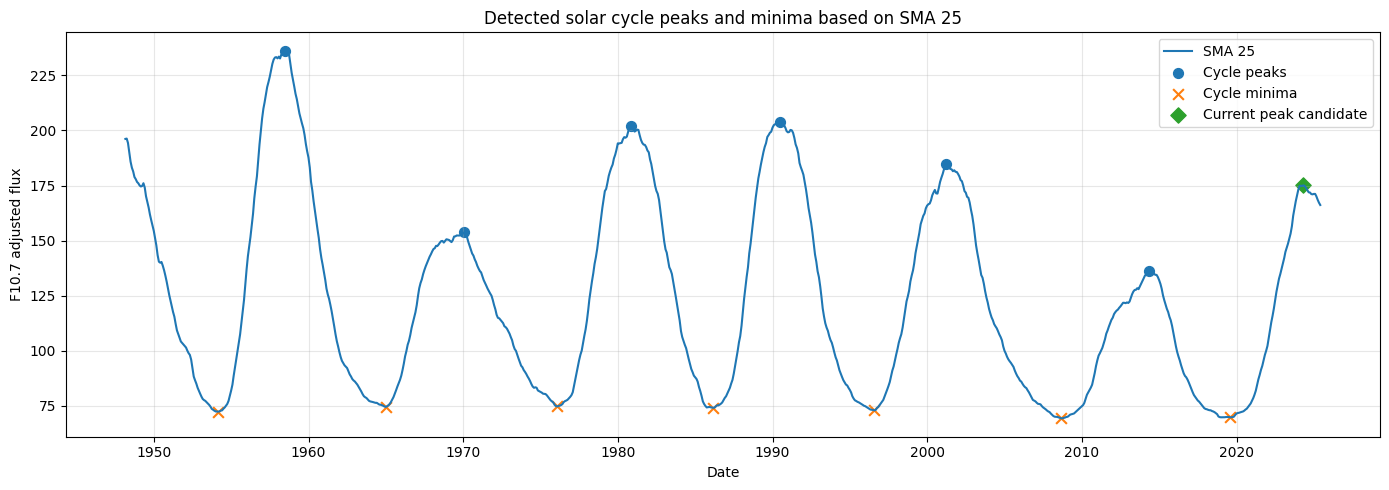

In [16]:
from scipy.signal import find_peaks


SMOOTH_COL = "sma_25"

cycle_data = df_monthly_smooth.dropna(subset=[SMOOTH_COL]).copy()


# максимумы и минимумы циклов по сглаженному ряду

peak_idx, _ = find_peaks(
    cycle_data[SMOOTH_COL],
    distance=80,
    prominence=15
)

min_idx, _ = find_peaks(
    -cycle_data[SMOOTH_COL],
    distance=80,
    prominence=10
)

cycle_peaks = cycle_data.iloc[peak_idx][["date", SMOOTH_COL]].copy()
cycle_mins = cycle_data.iloc[min_idx][["date", SMOOTH_COL]].copy()


# предварительный максимум текущего незавершённого цикла

last_min_date = cycle_mins["date"].max()
current_cycle = cycle_data[cycle_data["date"] > last_min_date].copy()

current_peak = current_cycle.loc[
    [current_cycle[SMOOTH_COL].idxmax()],
    ["date", SMOOTH_COL]
].copy()


print("Solar cycle peaks:")
display(cycle_peaks)

print("\nSolar cycle minima:")
display(cycle_mins)

print("\nCurrent peak candidate:")
display(current_peak)


plt.figure(figsize=(14, 5))

plt.plot(
    cycle_data["date"],
    cycle_data[SMOOTH_COL],
    linewidth=1.5,
    label="SMA 25"
)

plt.scatter(
    cycle_peaks["date"],
    cycle_peaks[SMOOTH_COL],
    marker="o",
    s=50,
    label="Cycle peaks"
)

plt.scatter(
    cycle_mins["date"],
    cycle_mins[SMOOTH_COL],
    marker="x",
    s=60,
    label="Cycle minima"
)

plt.scatter(
    current_peak["date"],
    current_peak[SMOOTH_COL],
    marker="D",
    s=60,
    label="Current peak candidate"
)

plt.title("Detected solar cycle peaks and minima based on SMA 25")
plt.xlabel("Date")
plt.ylabel("F10.7 adjusted flux")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.savefig(plots_dir / "14_detected_solar_cycle_peaks_minima.png", dpi=150)
plt.show()

In [17]:
SMOOTH_COL = "sma_25"

cycle_data = cycle_data.sort_values("date").copy()
cycle_mins_clean = cycle_mins.sort_values("date").reset_index(drop=True)

cycle_structure = []


# строим таблицу завершённых циклов: минимум, максимум, следующий минимум

for i in range(len(cycle_mins_clean) - 1):
    start_min = cycle_mins_clean.iloc[i]
    end_min = cycle_mins_clean.iloc[i + 1]

    segment = cycle_data[
        (cycle_data["date"] >= start_min["date"]) &
        (cycle_data["date"] <= end_min["date"])
    ]

    peak = segment.loc[segment[SMOOTH_COL].idxmax()]

    cycle_structure.append({
        "cycle_number": i + 1,
        "minimum_start": start_min["date"],
        "maximum_date": peak["date"],
        "minimum_end": end_min["date"],
        "minimum_start_f107": start_min[SMOOTH_COL],
        "maximum_f107": peak[SMOOTH_COL],
        "minimum_end_f107": end_min[SMOOTH_COL],
        "amplitude": peak[SMOOTH_COL] - start_min[SMOOTH_COL],
        "growth_years": (peak["date"] - start_min["date"]).days / 365.25,
        "decline_years": (end_min["date"] - peak["date"]).days / 365.25,
        "cycle_length_years": (end_min["date"] - start_min["date"]).days / 365.25
    })


cycle_structure_df = pd.DataFrame(cycle_structure)

round_cols = [
    "minimum_start_f107",
    "maximum_f107",
    "minimum_end_f107",
    "amplitude",
    "growth_years",
    "decline_years",
    "cycle_length_years"
]

cycle_structure_df[round_cols] = cycle_structure_df[round_cols].round(2)

cycle_structure_df.to_csv("f107_cycle_structure.csv", index=False)

display(cycle_structure_df)

,cycle_number,minimum_start,maximum_date,minimum_end,minimum_start_f107,maximum_f107,minimum_end_f107,amplitude,growth_years,decline_years,cycle_length_years
0,1,1954-02-28,1958-06-30,1964-12-31,72.38,236.18,74.50,163.79,4.33,6.51,10.84
1,2,1964-12-31,1970-01-31,1976-01-31,74.50,153.81,74.74,79.30,5.08,6.00,11.08
2,3,1976-01-31,1980-10-31,1986-02-28,74.74,201.97,74.12,127.23,4.75,5.33,10.08
3,4,1986-02-28,1990-06-30,1996-07-31,74.12,203.98,72.96,129.86,4.33,6.09,10.42
4,5,1996-07-31,2001-03-31,2008-08-31,72.96,184.59,69.33,111.63,4.67,7.42,12.08
5,6,2008-08-31,2014-04-30,2019-07-31,69.33,136.04,69.80,66.71,5.66,5.25,10.91


In [18]:
# проверяем, насколько оценка длины цикла зависит от окна сглаживания

windows = [9, 13, 17, 21, 25, 31]
results = []

for window in windows:
    smooth = (
        df_monthly["f107_adj"]
        .rolling(window=window, center=True)
        .mean()
    )

    smooth_data = df_monthly.loc[smooth.notna(), ["date"]].copy()
    smooth_data["smooth"] = smooth.dropna().values

    minima_idx, _ = find_peaks(
        -smooth_data["smooth"],
        distance=80
    )

    minima_dates = smooth_data.iloc[minima_idx]["date"]

    cycle_lengths = (
        minima_dates.diff().dt.days / 365.25
    ).dropna()

    results.append({
        "sma_window_months": window,
        "detected_cycles": len(cycle_lengths),
        "mean_period_years": cycle_lengths.mean(),
        "min_period_years": cycle_lengths.min(),
        "max_period_years": cycle_lengths.max()
    })


sensitivity_df = pd.DataFrame(results)

round_cols = [
    "mean_period_years",
    "min_period_years",
    "max_period_years"
]

sensitivity_df[round_cols] = sensitivity_df[round_cols].round(2)

sensitivity_df.to_csv("f107_smoothing_sensitivity.csv", index=False)

display(sensitivity_df)

,sma_window_months,detected_cycles,mean_period_years,min_period_years,max_period_years
0,9,6,10.94,9.66,12.34
1,13,6,10.93,9.67,12.42
2,17,6,10.86,9.91,12.42
3,21,6,10.93,10.33,11.75
4,25,6,10.90,10.08,12.08
5,31,6,10.85,9.84,12.42


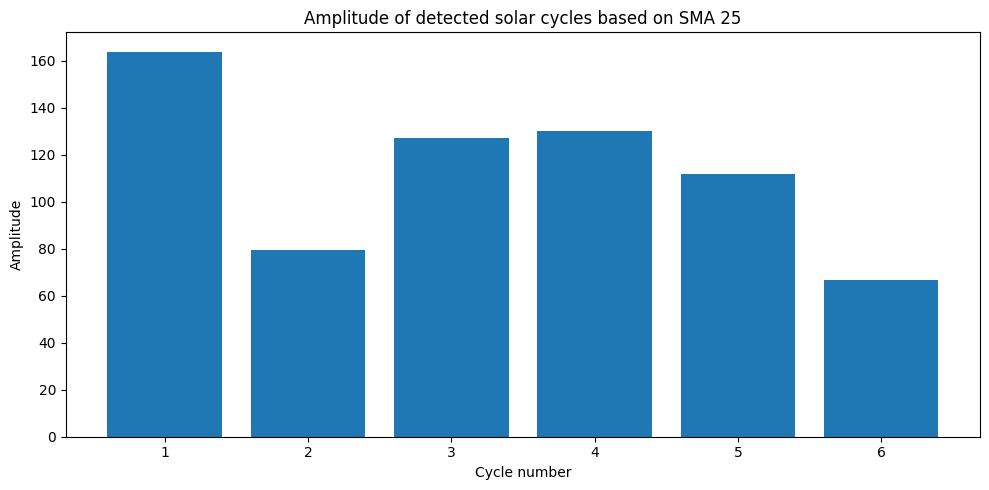

In [19]:
plt.figure(figsize=(10, 5))

plt.bar(
    cycle_structure_df["cycle_number"],
    cycle_structure_df["amplitude"]
)

plt.title("Amplitude of detected solar cycles based on SMA 25")
plt.xlabel("Cycle number")
plt.ylabel("Amplitude")

plt.tight_layout()
plt.savefig(plots_dir / "15_cycle_amplitudes.png", dpi=150)
plt.show()

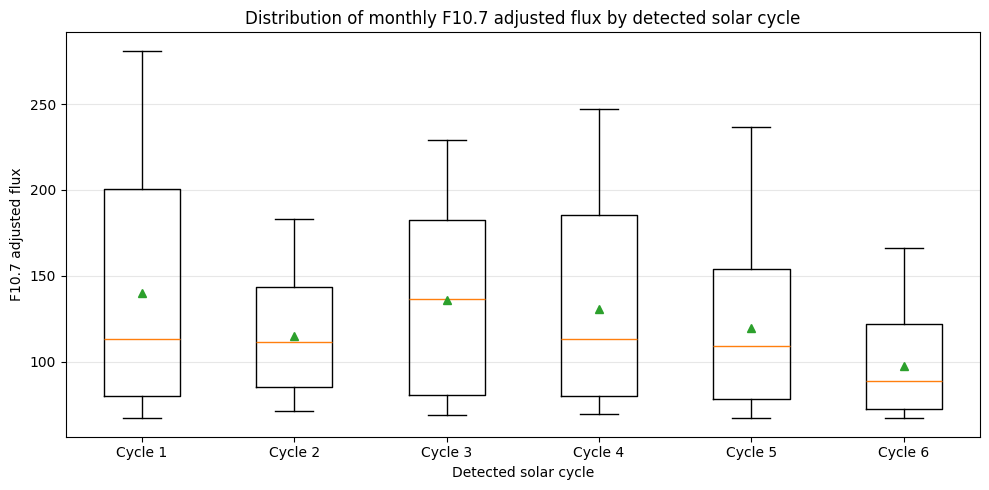

In [20]:
# распределение месячных значений F10.7 внутри завершённых циклов

cycle_box_data = []
cycle_labels = []

for row in cycle_structure_df.itertuples(index=False):
    mask = df_monthly["date"].between(
        row.minimum_start,
        row.minimum_end
    )

    cycle_box_data.append(
        df_monthly.loc[mask, "f107_adj"].dropna()
    )

    cycle_labels.append(f"Cycle {int(row.cycle_number)}")


plt.figure(figsize=(10, 5))

plt.boxplot(
    cycle_box_data,
    tick_labels=cycle_labels,
    showmeans=True
)

plt.title("Distribution of monthly F10.7 adjusted flux by detected solar cycle")
plt.xlabel("Detected solar cycle")
plt.ylabel("F10.7 adjusted flux")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(plots_dir / "16_cycle_boxplot_f107_distribution.png", dpi=150)
plt.show()

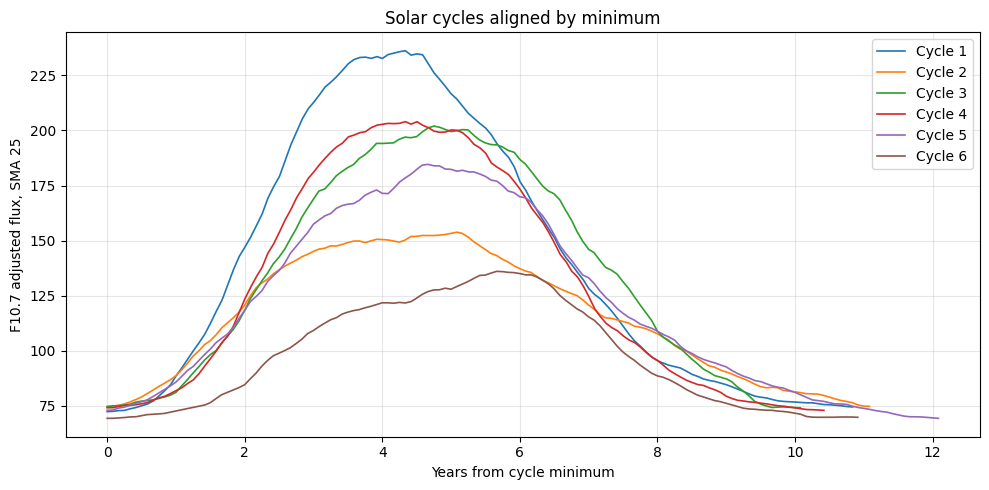

In [21]:
# сравниваем завершённые циклы, совместив их по минимуму

plt.figure(figsize=(10, 5))

for row in cycle_structure_df.itertuples(index=False):
    segment = cycle_data[
        cycle_data["date"].between(
            row.minimum_start,
            row.minimum_end
        )
    ]

    years_from_minimum = (
        segment["date"] - row.minimum_start
    ).dt.days / 365.25

    plt.plot(
        years_from_minimum,
        segment[SMOOTH_COL],
        linewidth=1.2,
        label=f"Cycle {int(row.cycle_number)}"
    )

plt.title("Solar cycles aligned by minimum")
plt.xlabel("Years from cycle minimum")
plt.ylabel("F10.7 adjusted flux, SMA 25")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.savefig(plots_dir / "17_solar_cycles_aligned_by_minimum.png", dpi=150)
plt.show()

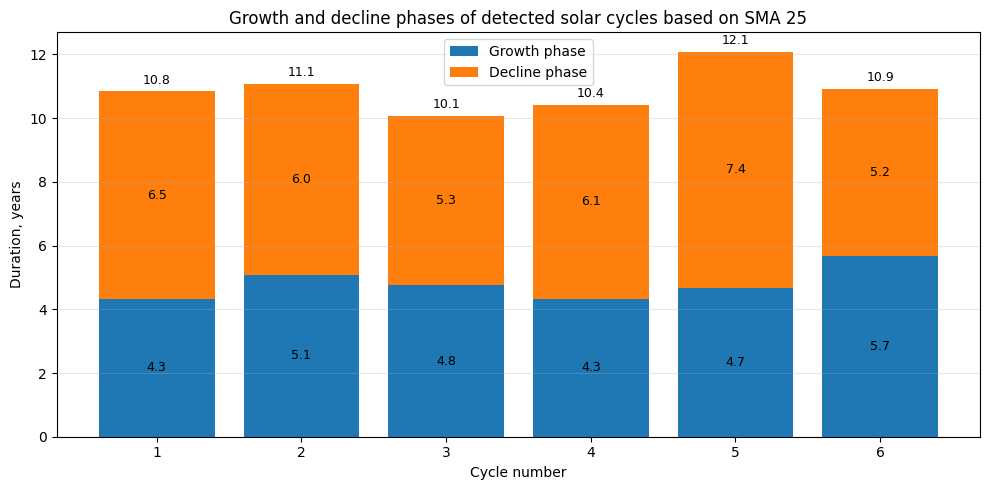

In [22]:
# длительность фаз роста и спада по завершённым циклам

plt.figure(figsize=(10, 5))

growth = cycle_structure_df["growth_years"]
decline = cycle_structure_df["decline_years"]
total = cycle_structure_df["cycle_length_years"]
cycles = cycle_structure_df["cycle_number"]

plt.bar(
    cycles,
    growth,
    label="Growth phase"
)

plt.bar(
    cycles,
    decline,
    bottom=growth,
    label="Decline phase"
)


for cycle, g, d, t in zip(cycles, growth, decline, total):
    plt.text(
        cycle,
        g / 2,
        f"{g:.1f}",
        ha="center",
        va="center",
        fontsize=9
    )

    plt.text(
        cycle,
        g + d / 2,
        f"{d:.1f}",
        ha="center",
        va="center",
        fontsize=9
    )

    plt.text(
        cycle,
        t + 0.15,
        f"{t:.1f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.xlabel("Cycle number")
plt.ylabel("Duration, years")
plt.title("Growth and decline phases of detected solar cycles based on SMA 25")
plt.grid(axis="y", alpha=0.3)
plt.legend()

plt.tight_layout()
plt.savefig(plots_dir / "18_cycle_growth_decline_phases.png", dpi=150)
plt.show()

# 5. Преобразование Фурье

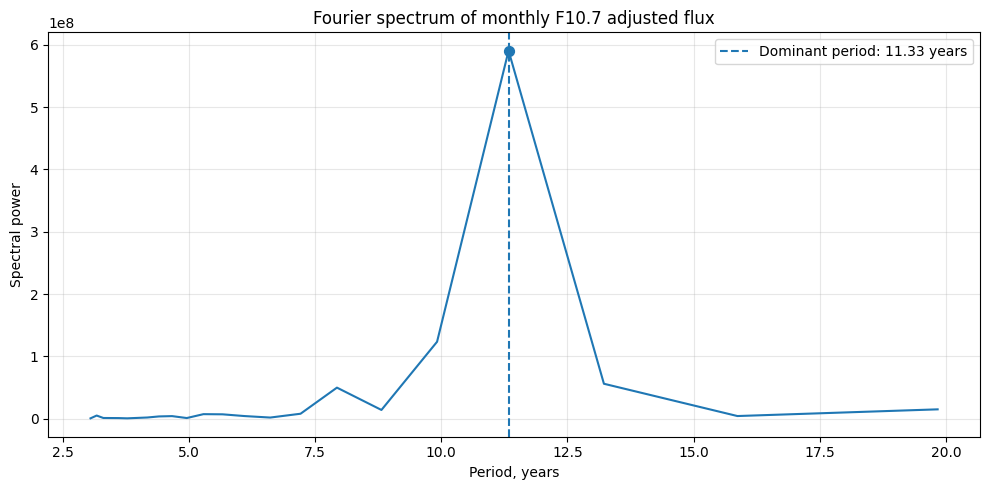

Dominant period: 11.33 years


In [23]:
# спектральный анализ месячного ряда F10.7

x = df_monthly["f107_adj"].dropna().values
x = x - x.mean()

fft_vals = np.fft.rfft(x)
power = np.abs(fft_vals) ** 2
freqs = np.fft.rfftfreq(len(x), d=1)

periods_years = 1 / (freqs[1:] * 12)
power = power[1:]

# смотрим периоды в диапазоне солнечных циклов

mask = (periods_years >= 3) & (periods_years <= 20)

dominant_period = periods_years[mask][
    np.argmax(power[mask])
]

dominant_power = power[mask][
    np.argmax(power[mask])
]


plt.figure(figsize=(10, 5))

plt.plot(
    periods_years[mask],
    power[mask],
    linewidth=1.5
)

plt.axvline(
    dominant_period,
    linestyle="--",
    linewidth=1.5,
    label=f"Dominant period: {dominant_period:.2f} years"
)

plt.scatter(
    dominant_period,
    dominant_power,
    s=50
)

plt.title("Fourier spectrum of monthly F10.7 adjusted flux")
plt.xlabel("Period, years")
plt.ylabel("Spectral power")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.savefig(plots_dir / "19_fft_monthly_f107_adj.png", dpi=150)
plt.show()


print("Dominant period:", round(dominant_period, 2), "years")

# 6. STL-декомпозиция

Best STL period: 128 months = 10.67 years


,period_months,period_years,cycle_strength,residual_std
8,128,10.67,0.745,24.421
6,126,10.50,0.743,24.435
7,127,10.58,0.729,25.171
2,122,10.17,0.727,25.133
5,125,10.42,0.725,25.358
9,129,10.75,0.716,25.881
3,123,10.25,0.711,25.968
4,124,10.33,0.708,26.158
10,130,10.83,0.704,26.420
11,131,10.92,0.701,26.716


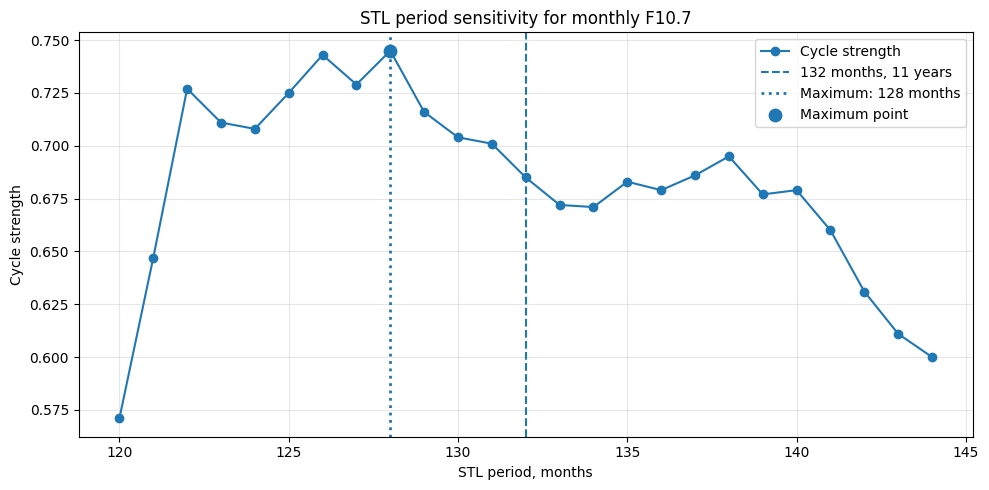

In [24]:
from statsmodels.tsa.seasonal import STL


# проверяем, какой период STL лучше выделяет циклическую структуру

CANONICAL_PERIOD = 132

monthly_series = (
    df_monthly
    .sort_values("date")
    .set_index("date")["f107_adj"]
    .dropna()
)

rows = []

for period in range(120, 145):
    result = STL(
        monthly_series,
        period=period,
        robust=True
    ).fit()

    cycle_strength = 1 - np.var(result.resid) / np.var(result.resid + result.seasonal)

    rows.append({
        "period_months": period,
        "period_years": period / 12,
        "cycle_strength": cycle_strength,
        "residual_std": np.std(result.resid)
    })


stl_sensitivity = pd.DataFrame(rows)

best_idx = stl_sensitivity["cycle_strength"].idxmax()
best_period = int(stl_sensitivity.loc[best_idx, "period_months"])
best_strength = stl_sensitivity.loc[best_idx, "cycle_strength"]

stl_sensitivity["period_years"] = stl_sensitivity["period_years"].round(2)
stl_sensitivity["cycle_strength"] = stl_sensitivity["cycle_strength"].round(3)
stl_sensitivity["residual_std"] = stl_sensitivity["residual_std"].round(3)

stl_sensitivity.to_csv("f107_stl_period_sensitivity.csv", index=False)


print(
    "Best STL period:",
    best_period,
    "months =",
    round(best_period / 12, 2),
    "years"
)

display(
    stl_sensitivity
    .sort_values(
        ["cycle_strength", "residual_std"],
        ascending=[False, True]
    )
    .head(10)
)


plt.figure(figsize=(10, 5))

plt.plot(
    stl_sensitivity["period_months"],
    stl_sensitivity["cycle_strength"],
    marker="o",
    label="Cycle strength"
)

plt.axvline(
    CANONICAL_PERIOD,
    linestyle="--",
    linewidth=1.5,
    label="132 months, 11 years"
)

plt.axvline(
    best_period,
    linestyle=":",
    linewidth=2,
    label=f"Maximum: {best_period} months"
)

plt.scatter(
    best_period,
    round(best_strength, 3),
    s=80,
    zorder=5,
    label="Maximum point"
)

plt.title("STL period sensitivity for monthly F10.7")
plt.xlabel("STL period, months")
plt.ylabel("Cycle strength")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.savefig(plots_dir / "20_stl_period_sensitivity_cycle_strength.png", dpi=150)
plt.show()

STL period: 128 months = 10.67 years


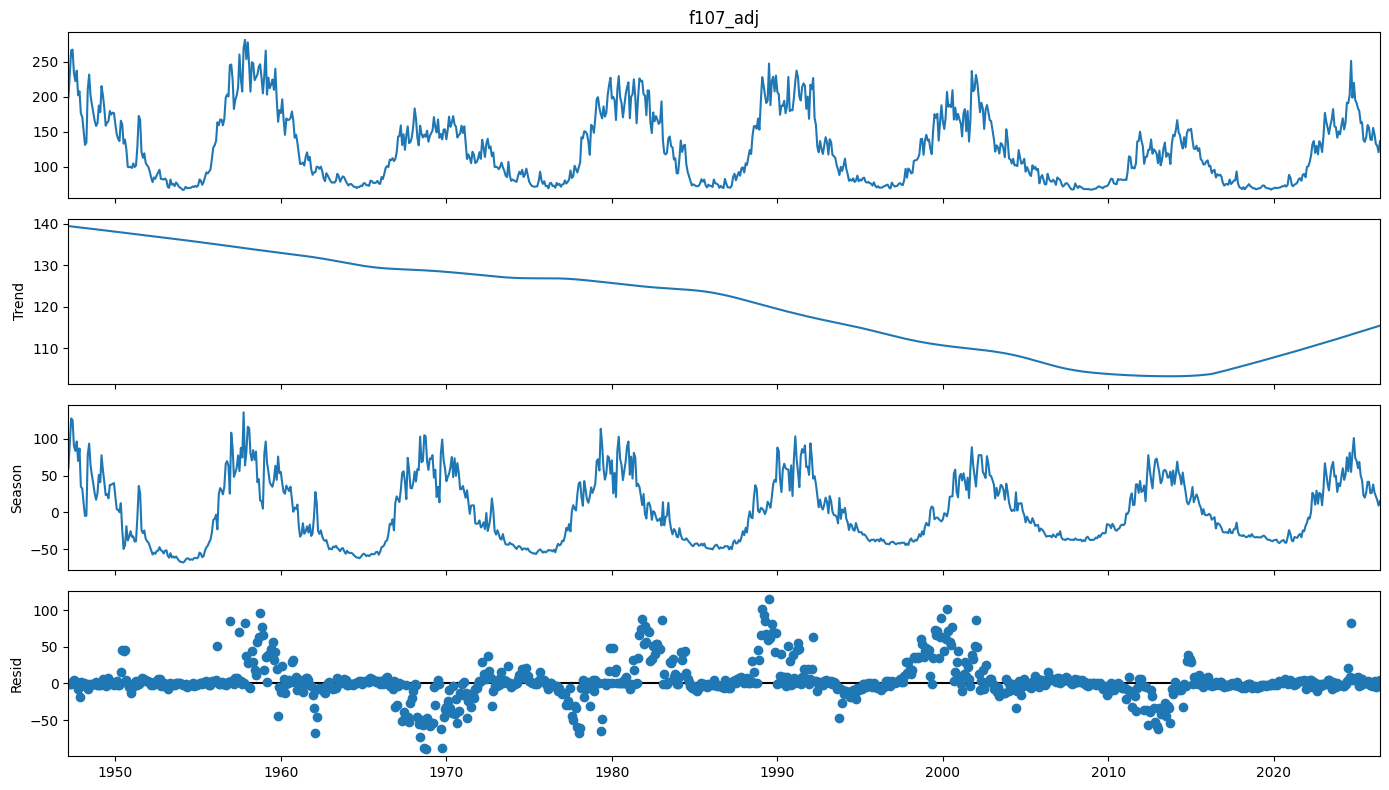

In [25]:
# STL-разложение месячного ряда на тренд, циклическую компоненту и остаток

STL_PERIOD = best_period

series = (
    df_monthly
    .sort_values("date")
    .set_index("date")["f107_adj"]
    .asfreq("ME")
    .interpolate()
)

result = STL(
    series,
    period=STL_PERIOD,
    robust=True
).fit()

print(
    "STL period:",
    STL_PERIOD,
    "months =",
    round(STL_PERIOD / 12, 2),
    "years"
)

fig = result.plot()
fig.set_size_inches(14, 8)

plt.tight_layout()
plt.savefig(plots_dir / "21_stl_monthly_f107_adj.png", dpi=150)
plt.show()

# 7. Автокорреляция и краткосрочные структуры

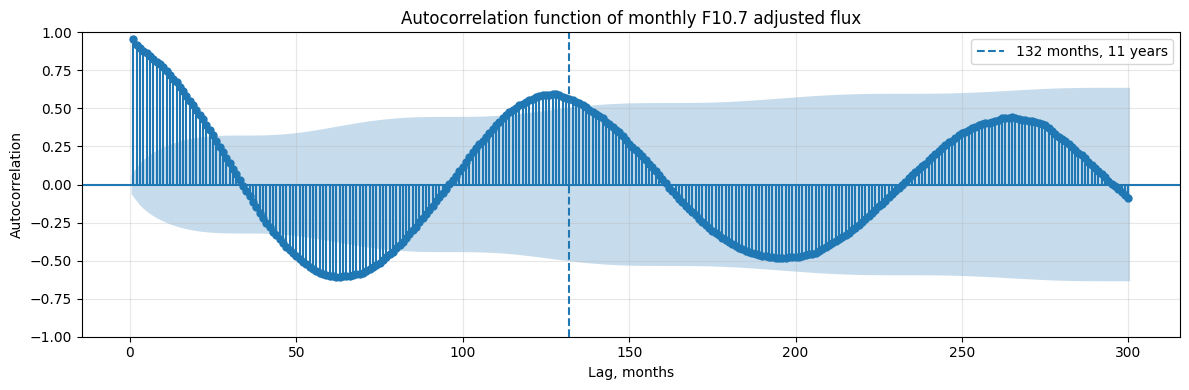

In [26]:
from statsmodels.graphics.tsaplots import plot_acf


# автокорреляция месячного ряда F10.7

series = (
    df_monthly
    .sort_values("date")
    .set_index("date")["f107_adj"]
    .dropna()
)

fig, ax = plt.subplots(figsize=(12, 4))

plot_acf(
    series,
    lags=300,
    zero=False,
    ax=ax
)

ax.axvline(
    132,
    linestyle="--",
    linewidth=1.5,
    label="132 months, 11 years"
)

ax.set_title("Autocorrelation function of monthly F10.7 adjusted flux")
ax.set_xlabel("Lag, months")
ax.set_ylabel("Autocorrelation")
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.savefig(plots_dir / "22_acf_monthly_f107_adj.png", dpi=150)
plt.show()

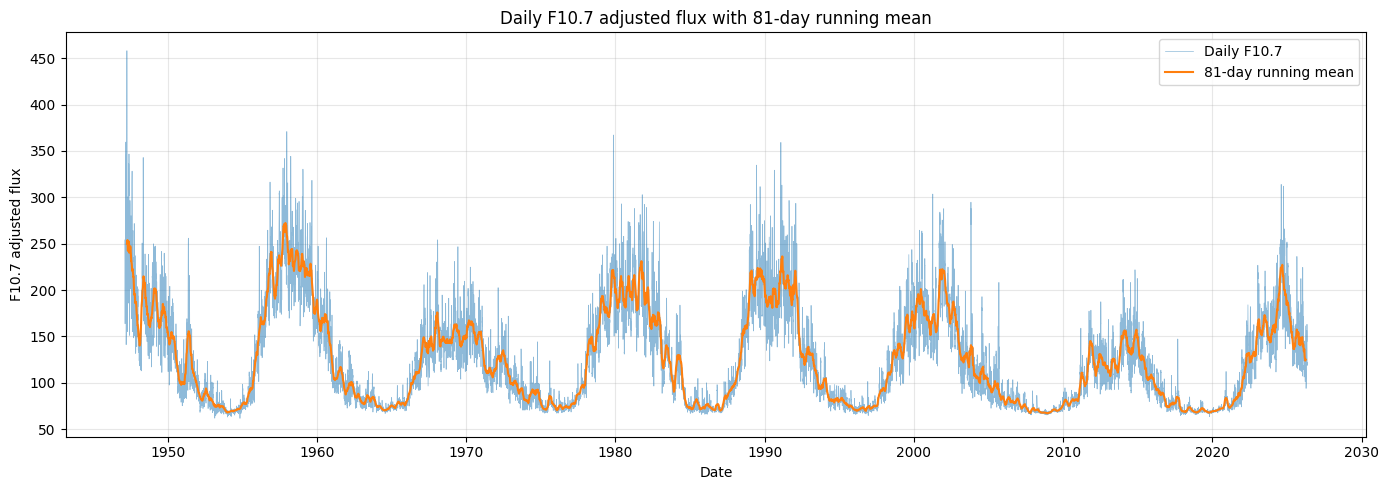

In [27]:
# дневной ряд и 81-дневное сглаживание
# 81 день это примерно три солнечные ротации по 27 дней

df_daily_81 = df_daily.copy()

df_daily_81["f107_adj_81d"] = (
    df_daily_81["f107_adj"]
    .rolling(window=81, center=True)
    .mean()
)


plt.figure(figsize=(14, 5))

plt.plot(
    df_daily_81["date"],
    df_daily_81["f107_adj"],
    linewidth=0.5,
    alpha=0.5,
    label="Daily F10.7"
)

plt.plot(
    df_daily_81["date"],
    df_daily_81["f107_adj_81d"],
    linewidth=1.5,
    label="81-day running mean"
)

plt.title("Daily F10.7 adjusted flux with 81-day running mean")
plt.xlabel("Date")
plt.ylabel("F10.7 adjusted flux")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.savefig(plots_dir / "23_daily_f107_81_day_running_mean.png", dpi=150)
plt.show()

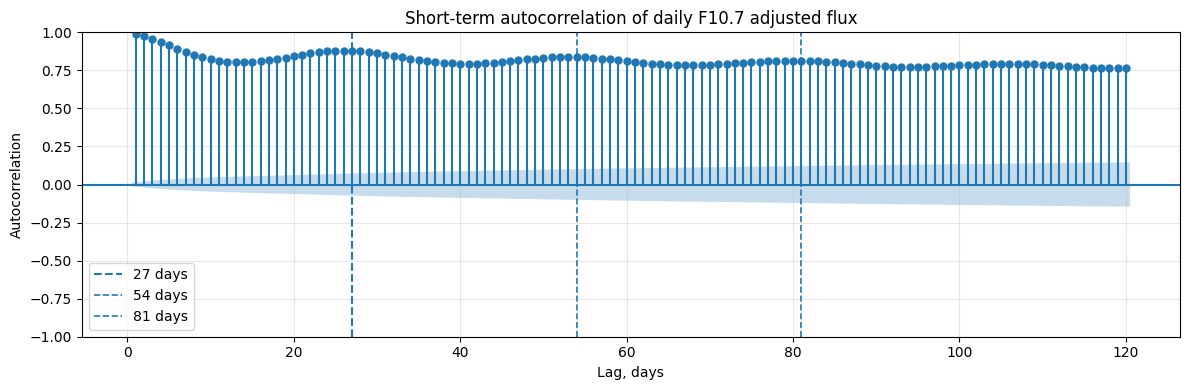

In [28]:
# краткосрочная автокорреляция дневного ряда
# 27, 54 и 81 день связаны с солнечной ротацией и её кратными

daily_series = (
    df_daily_full
    .sort_values("date")
    .set_index("date")["f107_adj"]
    .asfreq("D")
    .interpolate()
)

fig, ax = plt.subplots(figsize=(12, 4))

plot_acf(
    daily_series,
    lags=120,
    zero=False,
    ax=ax
)

for lag, width in [(27, 1.5), (54, 1.2), (81, 1.2)]:
    ax.axvline(
        lag,
        linestyle="--",
        linewidth=width,
        label=f"{lag} days"
    )

ax.set_title("Short-term autocorrelation of daily F10.7 adjusted flux")
ax.set_xlabel("Lag, days")
ax.set_ylabel("Autocorrelation")
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.savefig(plots_dir / "24_daily_f107_short_term_acf_27_days.png", dpi=150)
plt.show()

# 8. Сравнение оценок характерного периода

In [29]:
from statsmodels.tsa.stattools import acf


# итоговое сравнение оценок характерного периода F10.7

monthly_series = (
    df_monthly
    .sort_values("date")["f107_adj"]
    .dropna()
)

summary_rows = []


# 1. Оценка по минимумам циклов, найденным по SMA 25

cycle_periods = cycle_structure_df["cycle_length_years"]

summary_rows.append({
    "method": "Detected minima, SMA 25",
    "estimated_period_years": round(cycle_periods.mean(), 2),
    "details": (
        f"Mean minimum-to-minimum cycle length; "
        f"range {cycle_periods.min():.2f}-{cycle_periods.max():.2f} years"
    ),
    "comment": "Direct estimate from detected solar-cycle minima"
})


# 2. Оценка по месячной автокорреляции

acf_values = acf(
    monthly_series.values,
    nlags=240,
    fft=True
)

search_lags = np.arange(90, 171)

acf_peaks, _ = find_peaks(
    acf_values[search_lags]
)

if len(acf_peaks) > 0:
    peak_lags = search_lags[acf_peaks]
    best_acf_lag = peak_lags[np.argmax(acf_values[peak_lags])]
else:
    best_acf_lag = search_lags[np.argmax(acf_values[search_lags])]

summary_rows.append({
    "method": "Monthly ACF",
    "estimated_period_years": round(best_acf_lag / 12, 2),
    "details": f"Strongest ACF peak in solar-cycle range; lag = {best_acf_lag} months",
    "comment": "Checks recurrence of the monthly series"
})


# 3. Оценка по спектру Фурье

x = monthly_series.values - monthly_series.values.mean()

fft_values = np.fft.rfft(x)
power = np.abs(fft_values) ** 2
freqs = np.fft.rfftfreq(len(x), d=1)

periods_years = 1 / (freqs[1:] * 12)
power = power[1:]

fft_mask = (
    (periods_years >= 5) &
    (periods_years <= 20)
)

fft_period_years = periods_years[fft_mask][
    np.argmax(power[fft_mask])
]

summary_rows.append({
    "method": "FFT spectrum",
    "estimated_period_years": round(fft_period_years, 2),
    "details": "Dominant spectral period in the 5-20 year range",
    "comment": "Checks the strongest long-term frequency component"
})


# 4. Устойчивость оценки к окну сглаживания

if "sensitivity_df" in globals():
    sensitivity_periods = sensitivity_df["mean_period_years"]

    summary_rows.append({
        "method": "Smoothing sensitivity",
        "estimated_period_years": round(sensitivity_periods.mean(), 2),
        "details": (
            f"Mean across SMA windows; "
            f"range {sensitivity_periods.min():.2f}-{sensitivity_periods.max():.2f} years"
        ),
        "comment": "Checks whether the period estimate is stable under different smoothing windows"
    })


# 5. STL decomposition

if "best_period" in globals():
    stl_period_months = best_period
else:
    stl_period_months = 132

summary_rows.append({
    "method": "STL decomposition",
    "estimated_period_years": round(stl_period_months / 12, 2),
    "details": f"STL fitted with {stl_period_months}-month period",
    "comment": "Decomposition-based check of the long-term cyclic structure"
})


period_summary = pd.DataFrame(summary_rows)

period_summary.to_csv("f107_period_estimation_summary.csv", index=False)

display(period_summary)

,method,estimated_period_years,details,comment
0,"Detected minima, SMA 25",10.90,Mean minimum-to-minimum cycle length; range 10...,Direct estimate from detected solar-cycle minima
1,Monthly ACF,10.67,Strongest ACF peak in solar-cycle range; lag =...,Checks recurrence of the monthly series
2,FFT spectrum,11.33,Dominant spectral period in the 5-20 year range,Checks the strongest long-term frequency compo...
3,Smoothing sensitivity,10.90,Mean across SMA windows; range 10.85-10.94 years,Checks whether the period estimate is stable u...
4,STL decomposition,10.67,STL fitted with 128-month period,Decomposition-based check of the long-term cyc...


# 9. Анализ 27-дневной структуры

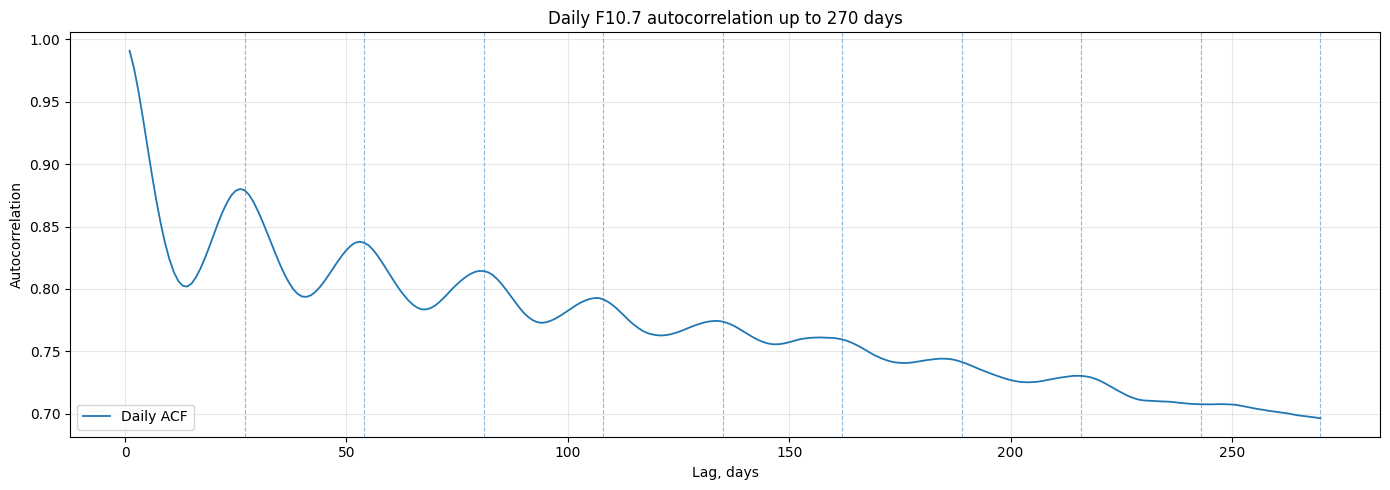

In [30]:
# проверяем краткосрочную автокорреляцию дневного ряда

MAX_LAG = 270
ROTATION_PERIOD = 27

daily_series = (
    df_daily_full
    .sort_values("date")
    .set_index("date")["f107_adj"]
    .asfreq("D")
    .interpolate()
)

acf_values = acf(
    daily_series.values,
    nlags=MAX_LAG,
    fft=True
)

acf_df = pd.DataFrame({
    "lag_days": np.arange(1, MAX_LAG + 1),
    "acf": acf_values[1:]
})


plt.figure(figsize=(14, 5))

plt.plot(
    acf_df["lag_days"],
    acf_df["acf"],
    linewidth=1.3,
    label="Daily ACF"
)

for lag in range(ROTATION_PERIOD, MAX_LAG + 1, ROTATION_PERIOD):
    plt.axvline(
        lag,
        linestyle="--",
        linewidth=0.8,
        alpha=0.5
    )

plt.title("Daily F10.7 autocorrelation up to 270 days")
plt.xlabel("Lag, days")
plt.ylabel("Autocorrelation")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.savefig(plots_dir / "25_daily_f107_acf_270_days_27_multiples.png", dpi=150)
plt.show()

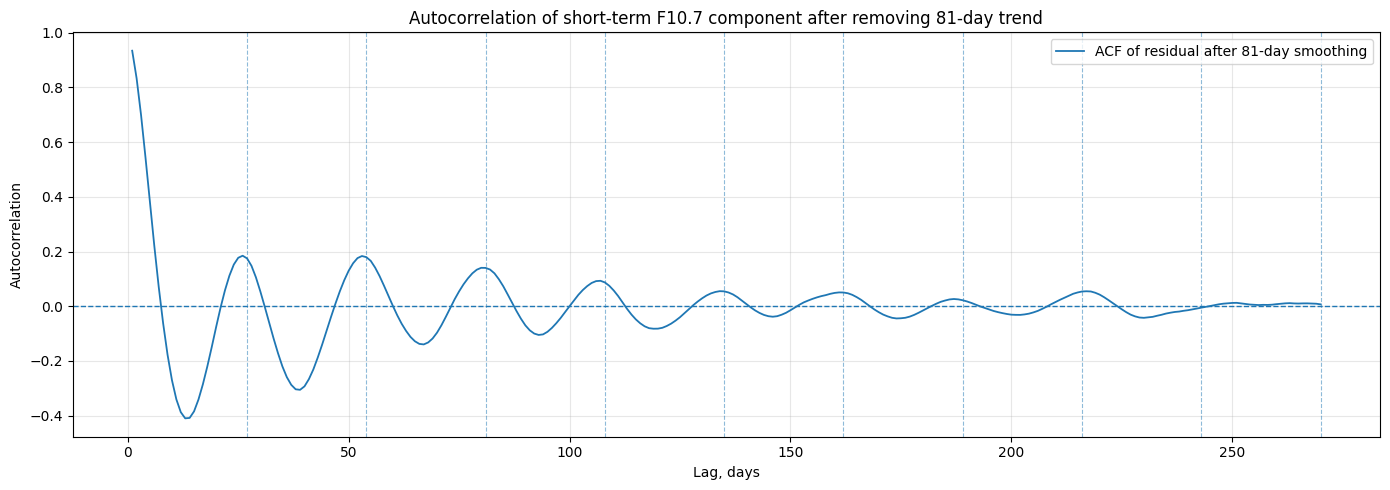

In [31]:
# ACF короткопериодной компоненты:
# убираем 81-дневное сглаживание и смотрим, остаётся ли 27-дневная структура

MAX_LAG = 270
ROTATION_PERIOD = 27

daily_series = (
    df_daily_full
    .sort_values("date")
    .set_index("date")["f107_adj"]
    .asfreq("D")
    .interpolate()
)

daily_trend_81 = (
    daily_series
    .rolling(window=81, center=True)
    .mean()
)

daily_residual_81 = (
    daily_series - daily_trend_81
).dropna()

acf_resid_values = acf(
    daily_residual_81.values,
    nlags=MAX_LAG,
    fft=True
)

acf_resid_df = pd.DataFrame({
    "lag_days": np.arange(1, MAX_LAG + 1),
    "acf": acf_resid_values[1:]
})


plt.figure(figsize=(14, 5))

plt.plot(
    acf_resid_df["lag_days"],
    acf_resid_df["acf"],
    linewidth=1.3,
    label="ACF of residual after 81-day smoothing"
)

for lag in range(ROTATION_PERIOD, MAX_LAG + 1, ROTATION_PERIOD):
    plt.axvline(
        lag,
        linestyle="--",
        linewidth=0.8,
        alpha=0.5
    )

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.title("Autocorrelation of short-term F10.7 component after removing 81-day trend")
plt.xlabel("Lag, days")
plt.ylabel("Autocorrelation")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.savefig(
    plots_dir / "26_daily_f107_acf_residual_81_day_27_multiples.png",
    dpi=150
)
plt.show()

# Предварительный блок перед прогнозированием

Correlation with previous month: 0.954


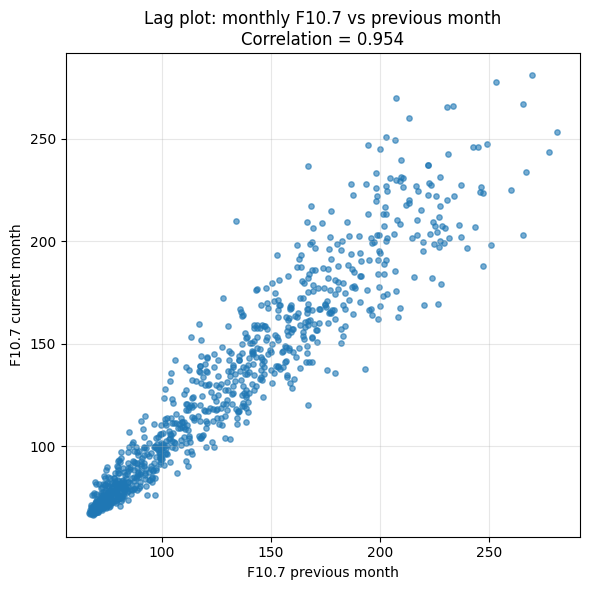

In [32]:
# лаговая связь месячного ряда перед прогнозным блоком

lag_df = df_monthly[["date", "f107_adj"]].copy()

lag_df["f107_lag_1"] = lag_df["f107_adj"].shift(1)

lag_df = lag_df.dropna()

lag_corr = lag_df["f107_lag_1"].corr(lag_df["f107_adj"])

print("Correlation with previous month:", round(lag_corr, 3))


plt.figure(figsize=(6, 6))

plt.scatter(
    lag_df["f107_lag_1"],
    lag_df["f107_adj"],
    s=15,
    alpha=0.6
)

plt.title(
    f"Lag plot: monthly F10.7 vs previous month\nCorrelation = {lag_corr:.3f}"
)

plt.xlabel("F10.7 previous month")
plt.ylabel("F10.7 current month")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(plots_dir / "27_monthly_f107_lag_1_scatter.png", dpi=150)
plt.show()

# 10. Прогнозный ML-блок

# ML-0. Общие настройки прогноза

In [33]:
# общие настройки для всех прогнозных экспериментов

import time
from sklearn.base import clone
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


RANDOM_STATE = 42
TRAIN_SHARE = 0.8

HORIZONS_MAIN = [1, 7, 27, 81, 180, 365, 730]
HORIZONS_ROTATION = [1, 7, 14, 27, 81]

ROTATION_DAYS = 27


# базовая дневная таблица для ML:
# один ряд на день, без пропусков в основном показателе

base_cols = ["f107_adj"]

if "carrington_rotation" in df_daily_full.columns:
    base_cols.append("carrington_rotation")

df_ml_base = (
    df_daily_full
    .sort_values("date")
    .set_index("date")[base_cols]
    .asfreq("D")
    .interpolate()
    .reset_index()
    .rename(columns={"f107_adj": "f107_now"})
)


# оценка длины крупного солнечного цикла по найденным минимумам

if "cycle_structure_df" in globals() and len(cycle_structure_df) > 0:
    CYCLE_YEARS = float(cycle_structure_df["cycle_length_years"].dropna().mean())

    anchor_candidates = pd.to_datetime(
        cycle_structure_df["minimum_start"],
        errors="coerce"
    ).dropna()

    if len(anchor_candidates) > 0:
        anchor_date = anchor_candidates.min()
    else:
        anchor_date = df_ml_base["date"].min()
else:
    CYCLE_YEARS = 11.0
    anchor_date = df_ml_base["date"].min()

CYCLE_DAYS = int(round(CYCLE_YEARS * 365.25))


models = {
    "Ridge": make_pipeline(
        StandardScaler(),
        Ridge(alpha=1.0)
    ),
    "RandomForest": RandomForestRegressor(
        n_estimators=150,
        max_depth=12,
        min_samples_leaf=5,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "HistGradientBoosting": HistGradientBoostingRegressor(
        max_iter=200,
        learning_rate=0.05,
        max_leaf_nodes=31,
        random_state=RANDOM_STATE
    )
}


models_fast = {
    "Ridge": make_pipeline(
        StandardScaler(),
        Ridge(alpha=1.0)
    ),
    "HistGradientBoosting": HistGradientBoostingRegressor(
        max_iter=100,
        learning_rate=0.05,
        max_leaf_nodes=31,
        random_state=RANDOM_STATE
    )
}


def calc_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred)
    }


def make_target(data, horizon, current_col="f107_now", target_col="target"):
    # сдвигаем ряд назад, чтобы получить значение через horizon дней
    data = data.copy()
    data[target_col] = data[current_col].shift(-horizon)
    return data


def time_train_test_split(data, train_share=TRAIN_SHARE):
    # делим ряд на train и test по времени, без перемешивания
    split_idx = int(len(data) * train_share)

    train = data.iloc[:split_idx]
    test = data.iloc[split_idx:]

    return train, test


def evaluate_feature_sets(
    data,
    feature_sets,
    horizon,
    models_dict=None,
    current_col="f107_now",
    target_col="target",
    add_persistence=True
):
    # проверяем, какой набор признаков лучше работает для данного горизонта

    # все варианты сравниваем на одинаковых датах,
    # чтобы разница была именно в признаках, а не в размере выборки

    if models_dict is None:
        models_dict = models

    data = data.copy()

    all_features = sorted(
        set(
            feature
            for features in feature_sets.values()
            for feature in features
        )
    )

    required_cols = [target_col] + all_features

    if add_persistence and current_col not in required_cols:
        required_cols.append(current_col)

    data = (
        data
        .dropna(subset=required_cols)
        .reset_index(drop=True)
    )

    train, test = time_train_test_split(data)

    y_train = train[target_col]
    y_test = test[target_col]

    results = []

    if add_persistence:
        persistence_pred = test[current_col]
        persistence_metrics = calc_metrics(y_test, persistence_pred)

        results.append({
            "horizon_days": horizon,
            "feature_set": "persistence",
            "model": "Persistence",
            "n_train": len(train),
            "n_test": len(test),
            **persistence_metrics
        })

    for feature_set_name, feature_cols in feature_sets.items():
        X_train = train[feature_cols]
        X_test = test[feature_cols]

        for model_name, model in models_dict.items():
            fitted_model = clone(model)
            fitted_model.fit(X_train, y_train)

            y_pred = fitted_model.predict(X_test)
            metrics = calc_metrics(y_test, y_pred)

            results.append({
                "horizon_days": horizon,
                "feature_set": feature_set_name,
                "model": model_name,
                "n_train": len(train),
                "n_test": len(test),
                **metrics
            })

    return pd.DataFrame(results)


def add_improvement_vs_current_only(results_df):
    # считаем, насколько модель лучше варианта current_only
    # сравнение идёт внутри одного горизонта и одной модели

    baseline = (
        results_df[results_df["feature_set"] == "current_only"]
        [["horizon_days", "model", "MAE"]]
        .rename(columns={"MAE": "MAE_current_only"})
    )

    out = results_df.merge(
        baseline,
        on=["horizon_days", "model"],
        how="left"
    )

    out["improvement_vs_current_only_%"] = (
        (out["MAE_current_only"] - out["MAE"])
        / out["MAE_current_only"]
        * 100
    )

    return out


def best_by_horizon_and_feature_set(results_df):
    # для каждого горизонта и набора признаков оставляем модель с минимальной MAE

    return (
        results_df
        .sort_values(["horizon_days", "feature_set", "MAE"])
        .groupby(["horizon_days", "feature_set"], as_index=False)
        .head(1)
        .reset_index(drop=True)
    )


print("ML base:", df_ml_base.shape)
print("Horizons:", HORIZONS_MAIN)
print("Cycle:", round(CYCLE_YEARS, 2), "years,", CYCLE_DAYS, "days")
print("Cycle anchor:", anchor_date)

ML base: (28939, 3)
Horizons: [1, 7, 27, 81, 180, 365, 730]
Cycle: 10.9 years, 3982 days
Cycle anchor: 1954-02-28 00:00:00


# ML-1. Базовый прогноз и persistence baseline

In [34]:
# базовый прогноз:
# сравниваем persistence baseline и модели только на текущем F10.7

start_time = time.time()

ml1_results = []

feature_sets_ml1 = {
    "current_only": ["f107_now"]
}

for horizon in HORIZONS_MAIN:
    data_h = make_target(
        df_ml_base,
        horizon=horizon,
        current_col="f107_now",
        target_col="target"
    )

    res_h = evaluate_feature_sets(
        data=data_h,
        feature_sets=feature_sets_ml1,
        horizon=horizon,
        models_dict=models,
        current_col="f107_now",
        target_col="target",
        add_persistence=True
    )

    ml1_results.append(res_h)


ml1_results = pd.concat(ml1_results, ignore_index=True)

ml1_results = (
    ml1_results
    .sort_values(["horizon_days", "MAE"])
    .reset_index(drop=True)
)


elapsed = time.time() - start_time

print("Время:", round(elapsed, 2), "сек.")

display(ml1_results)

Время: 26.17 сек.


,horizon_days,feature_set,model,n_train,n_test,MAE,RMSE,R2
0,1,persistence,Persistence,23150,5788,3.700708,5.806427,0.979426
1,1,current_only,Ridge,23150,5788,3.727854,5.792631,0.979523
2,1,current_only,HistGradientBoosting,23150,5788,3.735769,5.844714,0.979154
3,1,current_only,RandomForest,23150,5788,3.842509,6.004868,0.977996
4,7,persistence,Persistence,23145,5787,14.868291,22.608056,0.688092
5,7,current_only,HistGradientBoosting,23145,5787,15.019685,22.004706,0.704518
6,7,current_only,RandomForest,23145,5787,15.230619,22.410262,0.693526
7,7,current_only,Ridge,23145,5787,15.501083,21.807303,0.709796
8,27,persistence,Persistence,23129,5783,13.947138,20.437132,0.745147
9,27,current_only,HistGradientBoosting,23129,5783,14.294278,20.215967,0.750633


In [35]:
# лучшие результаты по каждому горизонту

ml1_best_by_horizon = (
    ml1_results
    .sort_values(["horizon_days", "MAE"])
    .groupby("horizon_days", as_index=False)
    .head(1)
    .reset_index(drop=True)
)

display(ml1_best_by_horizon)

,horizon_days,feature_set,model,n_train,n_test,MAE,RMSE,R2
0,1,persistence,Persistence,23150,5788,3.700708,5.806427,0.979426
1,7,persistence,Persistence,23145,5787,14.868291,22.608056,0.688092
2,27,persistence,Persistence,23129,5783,13.947138,20.437132,0.745147
3,81,persistence,Persistence,23086,5772,18.122089,26.455881,0.573235
4,180,current_only,HistGradientBoosting,23007,5752,20.098387,27.770989,0.530628
5,365,current_only,HistGradientBoosting,22859,5715,24.384482,31.709062,0.389247
6,730,current_only,Ridge,22567,5642,32.114882,38.797500,0.089934


In [36]:
# сравнение лучших моделей с persistence baseline

ml1_persistence = (
    ml1_results[ml1_results["feature_set"] == "persistence"]
    [["horizon_days", "MAE", "RMSE", "R2"]]
    .rename(columns={
        "MAE": "MAE_persistence",
        "RMSE": "RMSE_persistence",
        "R2": "R2_persistence"
    })
)

ml1_best_vs_persistence = (
    ml1_best_by_horizon
    .merge(ml1_persistence, on="horizon_days", how="left")
)

ml1_best_vs_persistence["MAE_improvement_vs_persistence_%"] = (
    (ml1_best_vs_persistence["MAE_persistence"] - ml1_best_vs_persistence["MAE"])
    / ml1_best_vs_persistence["MAE_persistence"]
    * 100
)

ml1_best_vs_persistence["beats_persistence"] = (
    ml1_best_vs_persistence["MAE"] < ml1_best_vs_persistence["MAE_persistence"]
)

display(ml1_best_vs_persistence)

,horizon_days,feature_set,model,n_train,n_test,MAE,RMSE,R2,MAE_persistence,RMSE_persistence,R2_persistence,MAE_improvement_vs_persistence_%,beats_persistence
0,1,persistence,Persistence,23150,5788,3.700708,5.806427,0.979426,3.700708,5.806427,0.979426,0.000000,False
1,7,persistence,Persistence,23145,5787,14.868291,22.608056,0.688092,14.868291,22.608056,0.688092,0.000000,False
2,27,persistence,Persistence,23129,5783,13.947138,20.437132,0.745147,13.947138,20.437132,0.745147,0.000000,False
3,81,persistence,Persistence,23086,5772,18.122089,26.455881,0.573235,18.122089,26.455881,0.573235,0.000000,False
4,180,current_only,HistGradientBoosting,23007,5752,20.098387,27.770989,0.530628,20.964656,30.637321,0.428737,4.132045,True
5,365,current_only,HistGradientBoosting,22859,5715,24.384482,31.709062,0.389247,25.737585,36.149697,0.206205,5.257303,True
6,730,current_only,Ridge,22567,5642,32.114882,38.797500,0.089934,34.986459,45.619458,-0.258247,8.207679,True


In [37]:
# сохранение результатов ML-1

ml1_results.to_csv("ml1_baseline_results.csv", index=False)
ml1_best_vs_persistence.to_csv("ml1_best_vs_persistence.csv", index=False)

print("Сохранено:")
print("ml1_baseline_results.csv")
print("ml1_best_vs_persistence.csv")

Сохранено:
ml1_baseline_results.csv
ml1_best_vs_persistence.csv


# ML-2. Структурные признаки 10-11-летнего цикла и режимов активности

Структурные признаки здесь - это положение в 10-11-летнем цикле, похожая фаза прошлого цикла и режимы активности. Дальше проверяю, помогают ли они в прогнозе по сравнению с current_only.

In [38]:
# структурные признаки для F10.7
# добавляем признаки цикла и режимов активности

start_time = time.time()

horizons = HORIZONS_MAIN

if "plots_dir" not in globals():
    plots_dir = Path("plots")
    plots_dir.mkdir(exist_ok=True)


# режимы считаем только по прошлым данным,
# чтобы не использовать будущее при прогнозе

df_ml_regime = df_ml_base.copy()
df_ml_regime["date"] = pd.to_datetime(df_ml_regime["date"])
df_ml_regime = df_ml_regime.sort_values("date").reset_index(drop=True)


monthly_regime_ml = (
    df_ml_regime
    .set_index("date")["f107_now"]
    .resample("ME")
    .mean()
    .reset_index()
    .rename(columns={"f107_now": "monthly_f107"})
)


monthly_regime_ml["sma_13_past"] = (
    monthly_regime_ml["monthly_f107"]
    .rolling(window=13)
    .mean()
)

monthly_regime_ml["slope_12m"] = (
    monthly_regime_ml["sma_13_past"]
    .diff(12) / 12
)

monthly_regime_ml["volatility_13m"] = (
    monthly_regime_ml["monthly_f107"]
    .rolling(window=13)
    .std()
)


# грубо делим состояние цикла на рост, спад и плато

plateau_limit = monthly_regime_ml["slope_12m"].abs().quantile(0.35)

monthly_regime_ml["cycle_state"] = np.select(
    [
        monthly_regime_ml["slope_12m"] > plateau_limit,
        monthly_regime_ml["slope_12m"] < -plateau_limit
    ],
    [
        "rising",
        "falling"
    ],
    default="plateau"
)


# уровень активности по сглаженному месячному F10.7

low_activity_limit = monthly_regime_ml["sma_13_past"].quantile(0.33)
high_activity_limit = monthly_regime_ml["sma_13_past"].quantile(0.66)

monthly_regime_ml["activity_level"] = np.select(
    [
        monthly_regime_ml["sma_13_past"] <= low_activity_limit,
        monthly_regime_ml["sma_13_past"] >= high_activity_limit
    ],
    [
        "low",
        "high"
    ],
    default="medium"
)


# отдельно отмечаем месяцы с высокой волатильностью

high_volatility_limit = monthly_regime_ml["volatility_13m"].quantile(0.75)

monthly_regime_ml["volatility_state"] = np.where(
    monthly_regime_ml["volatility_13m"] >= high_volatility_limit,
    "high",
    "normal"
)


# для каждого дня берём последний уже известный месячный режим

df_ml_regime = pd.merge_asof(
    df_ml_regime.sort_values("date"),
    monthly_regime_ml.sort_values("date"),
    on="date",
    direction="backward"
)


# категориальные режимы переводим в числовые признаки

regime_columns = [
    "cycle_state",
    "activity_level",
    "volatility_state"
]

df_ml_regime_encoded = pd.get_dummies(
    df_ml_regime,
    columns=regime_columns,
    drop_first=False
)


# bool-колонки переводим в 0 и 1

one_hot_cols = [
    col for col in df_ml_regime_encoded.columns
    if col.startswith("cycle_state_")
    or col.startswith("activity_level_")
    or col.startswith("volatility_state_")
]

df_ml_regime_encoded[one_hot_cols] = (
    df_ml_regime_encoded[one_hot_cols]
    .astype(int)
)


numeric_regime_features = [
    "sma_13_past",
    "slope_12m",
    "volatility_13m"
]

label_regime_features = one_hot_cols

all_regime_features = [
    *numeric_regime_features,
    *label_regime_features
]


df_ml_regime_encoded.to_csv(
    "f107_daily_with_regime_features_for_ml.csv",
    index=False
)


# сравниваем разные структурные признаки

ml2_results = []

for horizon in horizons:
    data_h = make_target(
        df_ml_regime_encoded,
        horizon=horizon,
        current_col="f107_now",
        target_col="target"
    )

    # фаза даты, которую пытаемся прогнозировать
    target_date = data_h["date"] + pd.to_timedelta(horizon, unit="D")
    days_from_anchor = (target_date - anchor_date).dt.days

    phase = 2 * np.pi * days_from_anchor / CYCLE_DAYS

    data_h["cycle_phase_sin"] = np.sin(phase)
    data_h["cycle_phase_cos"] = np.cos(phase)

    # значение из примерно такой же фазы прошлого крупного цикла
    cycle_lag = CYCLE_DAYS - horizon
    data_h["cycle_recurrence"] = data_h["f107_now"].shift(cycle_lag)

    cycle_phase_features = [
        "cycle_phase_sin",
        "cycle_phase_cos"
    ]

    cycle_recurrence_features = [
        "cycle_recurrence"
    ]

    full_cycle_features = [
        *cycle_phase_features,
        *cycle_recurrence_features
    ]

    feature_sets_ml2 = {
        "current_only": [
            "f107_now"
        ],

        "cycle_phase": [
            "f107_now",
            *cycle_phase_features
        ],

        "cycle_recurrence": [
            "f107_now",
            *cycle_recurrence_features
        ],

        "full_cycle": [
            "f107_now",
            *full_cycle_features
        ],

        "regime_numeric": [
            "f107_now",
            *numeric_regime_features
        ],

        "regime_all": [
            "f107_now",
            *all_regime_features
        ],

        "structural_all": [
            "f107_now",
            *full_cycle_features,
            *all_regime_features
        ]
    }

    res_h = evaluate_feature_sets(
        data=data_h,
        feature_sets=feature_sets_ml2,
        horizon=horizon,
        models_dict=models,
        current_col="f107_now",
        target_col="target",
        add_persistence=True
    )

    res_h["cycle_lag_days"] = cycle_lag

    ml2_results.append(res_h)


ml2_results = pd.concat(ml2_results, ignore_index=True)
ml2_results = add_improvement_vs_current_only(ml2_results)


round_cols = [
    "MAE",
    "RMSE",
    "R2",
    "MAE_current_only",
    "improvement_vs_current_only_%"
]

for col in round_cols:
    if col in ml2_results.columns:
        ml2_results[col] = ml2_results[col].round(3)


ml2_results = (
    ml2_results
    .sort_values(["horizon_days", "MAE"])
    .reset_index(drop=True)
)


ml2_gain = (
    ml2_results[
        ~ml2_results["feature_set"].isin([
            "persistence",
            "current_only"
        ])
    ]
    .sort_values(["horizon_days", "model", "MAE"])
    .reset_index(drop=True)
)


ml2_best_by_horizon = (
    ml2_results
    .sort_values(["horizon_days", "MAE"])
    .groupby("horizon_days", as_index=False)
    .head(1)
    .reset_index(drop=True)
)


ml2_best_by_feature_set = (
    ml2_results[
        ml2_results["feature_set"] != "persistence"
    ]
    .sort_values(["horizon_days", "feature_set", "MAE"])
    .groupby(["horizon_days", "feature_set"], as_index=False)
    .head(1)
    .reset_index(drop=True)
)


ml2_results.to_csv(
    "ml2_structural_features_results.csv",
    index=False
)

ml2_gain.to_csv(
    "ml2_structural_features_gain.csv",
    index=False
)

ml2_best_by_horizon.to_csv(
    "ml2_best_structural_by_horizon.csv",
    index=False
)


elapsed = time.time() - start_time

print("Время:", round(elapsed, 2), "сек.")

display(ml2_best_by_horizon)

Время: 419.4 сек.


,horizon_days,feature_set,model,n_train,n_test,MAE,RMSE,R2,cycle_lag_days,MAE_current_only,improvement_vs_current_only_%
0,1,structural_all,Ridge,19965,4992,3.744,5.896,0.981,3981,3.774,0.780
1,7,structural_all,HistGradientBoosting,19965,4992,13.559,20.385,0.769,3975,15.079,10.085
2,27,structural_all,HistGradientBoosting,19965,4992,13.515,19.627,0.786,3955,14.192,4.773
3,81,structural_all,RandomForest,19965,4992,15.776,22.865,0.709,3901,18.033,12.519
4,180,structural_all,HistGradientBoosting,19965,4992,17.301,24.519,0.666,3802,19.905,13.079
5,365,cycle_phase,HistGradientBoosting,19965,4992,19.773,27.760,0.572,3617,24.652,19.790
6,730,cycle_phase,HistGradientBoosting,19965,4992,22.337,30.073,0.497,3252,33.679,33.678


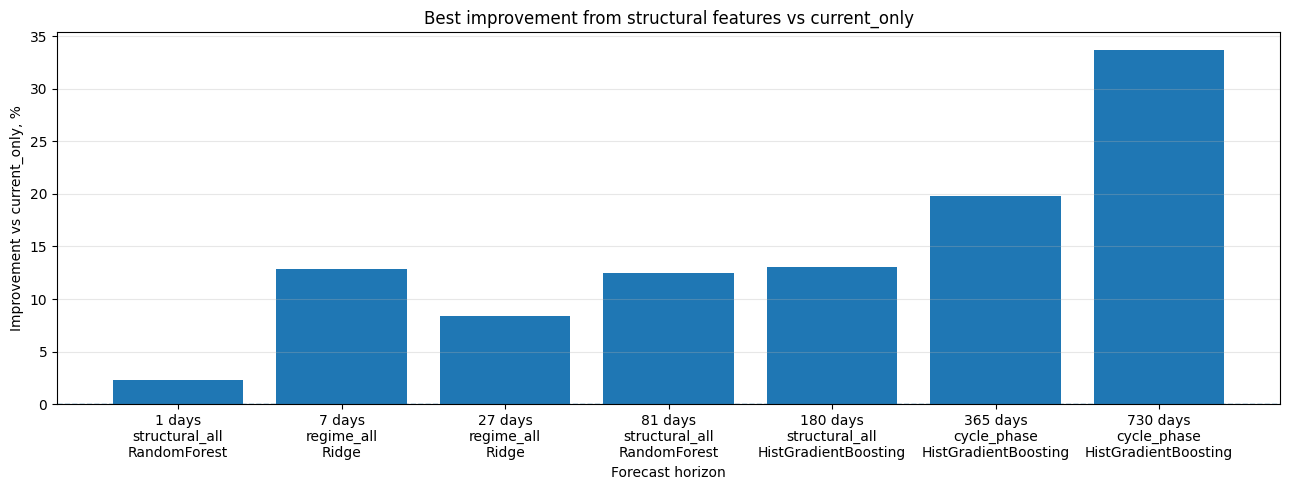

In [39]:
# график лучшего прироста от структурных признаков относительно current_only

best_gain_plot = (
    ml2_gain
    .sort_values(
        ["horizon_days", "improvement_vs_current_only_%"],
        ascending=[True, False]
    )
    .groupby("horizon_days", as_index=False)
    .head(1)
    .copy()
)

best_gain_plot["label"] = (
    best_gain_plot["horizon_days"].astype(str)
    + " days\n"
    + best_gain_plot["feature_set"]
    + "\n"
    + best_gain_plot["model"]
)

plt.figure(figsize=(13, 5))

plt.bar(
    best_gain_plot["label"],
    best_gain_plot["improvement_vs_current_only_%"]
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.title("Best improvement from structural features vs current_only")
plt.xlabel("Forecast horizon")
plt.ylabel("Improvement vs current_only, %")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(
    plots_dir / "28_ml_structural_features_best_improvement.png",
    dpi=150
)
plt.show()

# ML-3. Стандартные признаки против структурных признаков

In [40]:
# сравниваем лаги и rolling-статистики со структурными признаками

start_time = time.time()

horizons = HORIZONS_MAIN

# берём таблицу с режимами из прошлого блока
df_ml3 = df_ml_regime_encoded.copy()
df_ml3["date"] = pd.to_datetime(df_ml3["date"])
df_ml3 = df_ml3.sort_values("date").reset_index(drop=True)


# обычные признаки: лаги и rolling-статистики

lag_days = [1, 7, 27, 81, 180, 365]
rolling_windows = [7, 27, 81, 180, 365]

standard_features = []

for lag in lag_days:
    col = f"lag_{lag}"
    df_ml3[col] = df_ml3["f107_now"].shift(lag)
    standard_features.append(col)

for window in rolling_windows:
    mean_col = f"rolling_mean_{window}"
    std_col = f"rolling_std_{window}"

    df_ml3[mean_col] = df_ml3["f107_now"].rolling(window=window).mean()
    df_ml3[std_col] = df_ml3["f107_now"].rolling(window=window).std()

    standard_features.extend([mean_col, std_col])


# режимные признаки уже были посчитаны раньше

regime_features = [
    col for col in df_ml3.columns
    if col in all_regime_features
]


ml3_results = []

for horizon in horizons:
    data_h = make_target(
        df_ml3,
        horizon=horizon,
        current_col="f107_now",
        target_col="target"
    )

    # фаза даты, которую прогнозируем
    target_date = data_h["date"] + pd.to_timedelta(horizon, unit="D")
    days_from_anchor = (target_date - anchor_date).dt.days

    phase = 2 * np.pi * days_from_anchor / CYCLE_DAYS

    data_h["cycle_phase_sin"] = np.sin(phase)
    data_h["cycle_phase_cos"] = np.cos(phase)

    # значение из похожей фазы прошлого крупного цикла
    cycle_lag = CYCLE_DAYS - horizon
    data_h["cycle_recurrence"] = data_h["f107_now"].shift(cycle_lag)

    cycle_features = [
        "cycle_phase_sin",
        "cycle_phase_cos",
        "cycle_recurrence"
    ]

    structural_features = [
        *cycle_features,
        *regime_features
    ]

    feature_sets_ml3 = {
        "current_only": [
            "f107_now"
        ],

        "standard_lag_rolling": [
            "f107_now",
            *standard_features
        ],

        "structural_all": [
            "f107_now",
            *structural_features
        ],

        "standard_plus_structural": [
            "f107_now",
            *standard_features,
            *structural_features
        ]
    }

    res_h = evaluate_feature_sets(
        data=data_h,
        feature_sets=feature_sets_ml3,
        horizon=horizon,
        models_dict=models,
        current_col="f107_now",
        target_col="target",
        add_persistence=True
    )

    ml3_results.append(res_h)


ml3_results = pd.concat(ml3_results, ignore_index=True)
ml3_results = add_improvement_vs_current_only(ml3_results)


round_cols = [
    "MAE",
    "RMSE",
    "R2",
    "MAE_current_only",
    "improvement_vs_current_only_%"
]

for col in round_cols:
    if col in ml3_results.columns:
        ml3_results[col] = ml3_results[col].round(3)


ml3_results = (
    ml3_results
    .sort_values(["horizon_days", "MAE"])
    .reset_index(drop=True)
)


ml3_best_by_feature_set = (
    ml3_results[
        ml3_results["feature_set"] != "persistence"
    ]
    .sort_values(["horizon_days", "feature_set", "MAE"])
    .groupby(["horizon_days", "feature_set"], as_index=False)
    .head(1)
    .reset_index(drop=True)
)


ml3_best_by_horizon = (
    ml3_results
    .sort_values(["horizon_days", "MAE"])
    .groupby("horizon_days", as_index=False)
    .head(1)
    .reset_index(drop=True)
)


ml3_results.to_csv(
    "ml3_standard_vs_structural_results.csv",
    index=False
)

ml3_best_by_feature_set.to_csv(
    "ml3_standard_vs_structural_best_by_feature_set.csv",
    index=False
)

ml3_best_by_horizon.to_csv(
    "ml3_standard_vs_structural_best_by_horizon.csv",
    index=False
)


elapsed = time.time() - start_time

print("Время:", round(elapsed, 2), "сек.")

display(ml3_best_by_horizon)

Время: 977.18 сек.


,horizon_days,feature_set,model,n_train,n_test,MAE,RMSE,R2,MAE_current_only,improvement_vs_current_only_%
0,1,standard_lag_rolling,Ridge,19965,4992,3.248,5.235,0.985,3.774,13.934
1,7,standard_lag_rolling,Ridge,19965,4992,11.330,16.774,0.844,15.771,28.158
2,27,standard_lag_rolling,Ridge,19965,4992,13.135,19.141,0.796,14.759,11.004
3,81,structural_all,RandomForest,19965,4992,15.776,22.865,0.709,18.033,12.519
4,180,structural_all,HistGradientBoosting,19965,4992,17.301,24.519,0.666,19.905,13.079
5,365,structural_all,HistGradientBoosting,19965,4992,19.823,26.655,0.605,24.652,19.588
6,730,structural_all,HistGradientBoosting,19965,4992,24.422,31.148,0.461,33.679,27.488


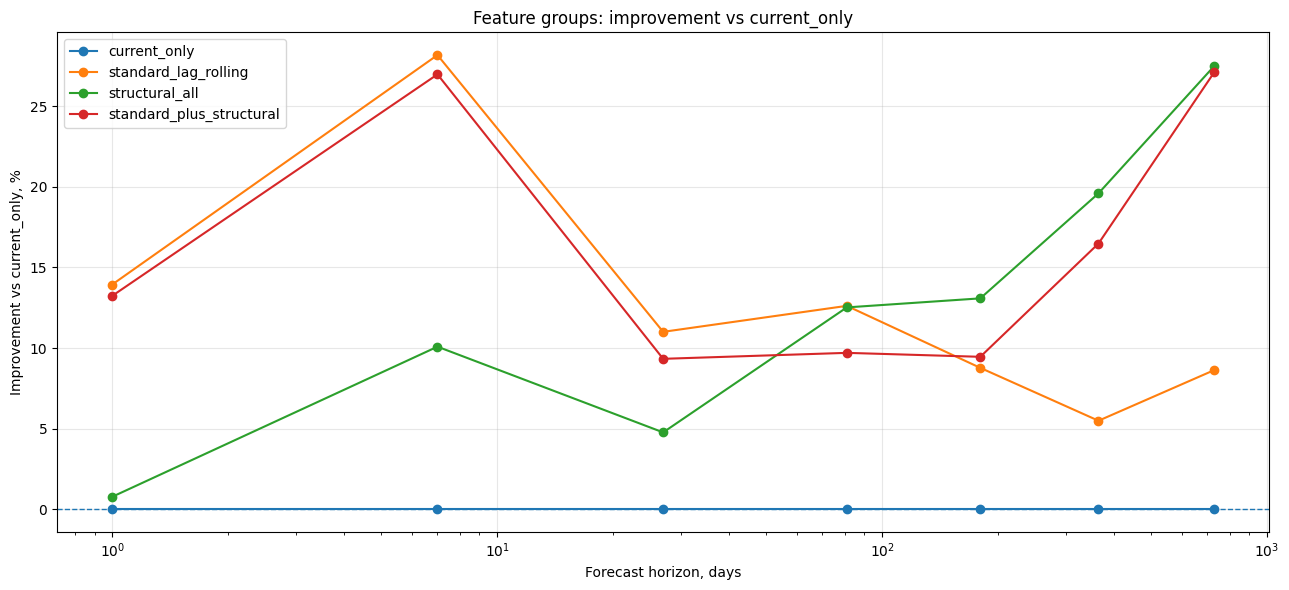

In [41]:
# сравнение обычных, структурных и объединённых признаков

plot_ml3 = ml3_best_by_feature_set.copy()

plot_ml3 = plot_ml3[
    plot_ml3["feature_set"].isin([
        "current_only",
        "standard_lag_rolling",
        "structural_all",
        "standard_plus_structural"
    ])
].copy()

plt.figure(figsize=(13, 6))

for feature_set in [
    "current_only",
    "standard_lag_rolling",
    "structural_all",
    "standard_plus_structural"
]:
    subset = plot_ml3[plot_ml3["feature_set"] == feature_set]

    plt.plot(
        subset["horizon_days"],
        subset["improvement_vs_current_only_%"],
        marker="o",
        label=feature_set
    )

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.title("Feature groups: improvement vs current_only")
plt.xlabel("Forecast horizon, days")
plt.ylabel("Improvement vs current_only, %")
plt.xscale("log")
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.savefig(
    plots_dir / "29_ml_feature_groups_improvement.png",
    dpi=150
)
plt.show()

# ML-4. Признаки 27-дневной ротационной структуры

In [42]:
# отдельно проверяем 27-дневные признаки

start_time = time.time()

horizons = HORIZONS_ROTATION

df_ml4 = df_ml_base.copy()
df_ml4["date"] = pd.to_datetime(df_ml4["date"])
df_ml4 = df_ml4.sort_values("date").reset_index(drop=True)


# лаги на масштабе одного, двух и трёх солнечных оборотов

rotation_lags = [27, 54, 81]

rotation_features = []

for lag in rotation_lags:
    lag_col = f"rot_lag_{lag}"
    diff_col = f"rot_diff_{lag}"

    df_ml4[lag_col] = df_ml4["f107_now"].shift(lag)
    df_ml4[diff_col] = df_ml4["f107_now"] - df_ml4[lag_col]

    rotation_features.extend([lag_col, diff_col])


# локальная статистика на 27 и 81 день

for window in [27, 81]:
    mean_col = f"rot_rolling_mean_{window}"
    std_col = f"rot_rolling_std_{window}"

    df_ml4[mean_col] = df_ml4["f107_now"].rolling(window=window).mean()
    df_ml4[std_col] = df_ml4["f107_now"].rolling(window=window).std()

    rotation_features.extend([mean_col, std_col])


ml4_results = []

for horizon in horizons:
    data_h = make_target(
        df_ml4,
        horizon=horizon,
        current_col="f107_now",
        target_col="target"
    )

    # простая фаза для условного 27-дневного периода

    target_date = data_h["date"] + pd.to_timedelta(horizon, unit="D")
    days_from_anchor = (target_date - anchor_date).dt.days

    rotation_phase = 2 * np.pi * days_from_anchor / ROTATION_DAYS

    data_h["rotation_phase_sin"] = np.sin(rotation_phase)
    data_h["rotation_phase_cos"] = np.cos(rotation_phase)

    rotation_phase_features = [
        "rotation_phase_sin",
        "rotation_phase_cos"
    ]

    feature_sets_ml4 = {
        "current_only": [
            "f107_now"
        ],

        "rotation_lags": [
            "f107_now",
            "rot_lag_27",
            "rot_lag_54",
            "rot_lag_81"
        ],

        "rotation_differences": [
            "f107_now",
            "rot_diff_27",
            "rot_diff_54",
            "rot_diff_81"
        ],

        "rotation_local_stats": [
            "f107_now",
            "rot_rolling_mean_27",
            "rot_rolling_std_27",
            "rot_rolling_mean_81",
            "rot_rolling_std_81"
        ],

        "rotation_phase": [
            "f107_now",
            *rotation_phase_features
        ],

        "rotation_all": [
            "f107_now",
            *rotation_features,
            *rotation_phase_features
        ]
    }

    res_h = evaluate_feature_sets(
        data=data_h,
        feature_sets=feature_sets_ml4,
        horizon=horizon,
        models_dict=models_fast,
        current_col="f107_now",
        target_col="target",
        add_persistence=True
    )

    ml4_results.append(res_h)


ml4_results = pd.concat(ml4_results, ignore_index=True)
ml4_results = add_improvement_vs_current_only(ml4_results)


round_cols = [
    "MAE",
    "RMSE",
    "R2",
    "MAE_current_only",
    "improvement_vs_current_only_%"
]

for col in round_cols:
    if col in ml4_results.columns:
        ml4_results[col] = ml4_results[col].round(3)


ml4_results = (
    ml4_results
    .sort_values(["horizon_days", "MAE"])
    .reset_index(drop=True)
)


ml4_gain = (
    ml4_results[
        ~ml4_results["feature_set"].isin([
            "persistence",
            "current_only"
        ])
    ]
    .sort_values(["horizon_days", "model", "MAE"])
    .reset_index(drop=True)
)


ml4_best_by_feature_set = (
    ml4_results[
        ml4_results["feature_set"] != "persistence"
    ]
    .sort_values(["horizon_days", "feature_set", "MAE"])
    .groupby(["horizon_days", "feature_set"], as_index=False)
    .head(1)
    .reset_index(drop=True)
)


ml4_best_by_horizon = (
    ml4_results
    .sort_values(["horizon_days", "MAE"])
    .groupby("horizon_days", as_index=False)
    .head(1)
    .reset_index(drop=True)
)


ml4_results.to_csv(
    "ml4_27day_rotation_features_results.csv",
    index=False
)

ml4_gain.to_csv(
    "ml4_27day_rotation_features_gain.csv",
    index=False
)

ml4_best_by_feature_set.to_csv(
    "ml4_27day_rotation_best_by_feature_set.csv",
    index=False
)

ml4_best_by_horizon.to_csv(
    "ml4_27day_rotation_best_by_horizon.csv",
    index=False
)


elapsed = time.time() - start_time

print("Время:", round(elapsed, 2), "сек.")

display(ml4_best_by_horizon)

Время: 15.55 сек.


,horizon_days,feature_set,model,n_train,n_test,MAE,RMSE,R2,MAE_current_only,improvement_vs_current_only_%
0,1,rotation_local_stats,Ridge,23085,5772,3.704,5.769,0.980,3.732,0.750
1,7,rotation_local_stats,Ridge,23080,5771,12.603,18.396,0.794,15.472,18.544
2,14,rotation_all,Ridge,23075,5769,12.898,18.412,0.793,18.991,32.083
3,27,rotation_local_stats,Ridge,23064,5767,13.008,18.471,0.792,14.566,10.694
4,81,rotation_local_stats,Ridge,23021,5756,16.358,23.082,0.676,18.549,11.812


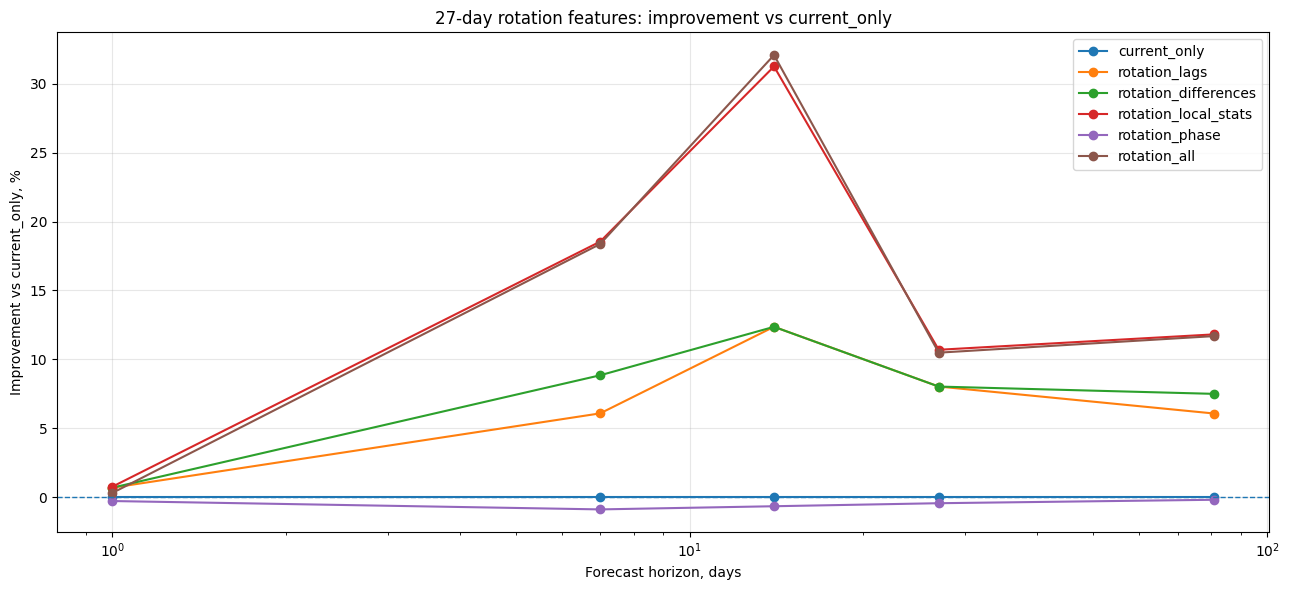

In [43]:
# график вклада 27-дневных признаков относительно current_only

plot_ml4 = ml4_best_by_feature_set.copy()

plot_ml4 = plot_ml4[
    plot_ml4["feature_set"].isin([
        "current_only",
        "rotation_lags",
        "rotation_differences",
        "rotation_local_stats",
        "rotation_phase",
        "rotation_all"
    ])
].copy()

plt.figure(figsize=(13, 6))

for feature_set in [
    "current_only",
    "rotation_lags",
    "rotation_differences",
    "rotation_local_stats",
    "rotation_phase",
    "rotation_all"
]:
    subset = plot_ml4[plot_ml4["feature_set"] == feature_set]

    plt.plot(
        subset["horizon_days"],
        subset["improvement_vs_current_only_%"],
        marker="o",
        label=feature_set
    )

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.title("27-day rotation features: improvement vs current_only")
plt.xlabel("Forecast horizon, days")
plt.ylabel("Improvement vs current_only, %")
plt.xscale("log")
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.savefig(
    plots_dir / "30_ml_27day_rotation_improvement.png",
    dpi=150
)
plt.show()

# ML-5. Анализ ошибки прогноза по режимам активности

In [44]:
# анализируем, где прогноз ошибается сильнее:
# на росте/спаде цикла, при разном уровне активности и разной волатильности

start_time = time.time()

df_ml5 = df_ml_regime_encoded.copy()
df_ml5["date"] = pd.to_datetime(df_ml5["date"])
df_ml5 = df_ml5.sort_values("date").reset_index(drop=True)


# one-hot колонки переводим обратно в обычные метки

def restore_label(data, prefix, output_col):
    cols = [col for col in data.columns if col.startswith(prefix)]

    if output_col not in data.columns:
        data[output_col] = (
            data[cols]
            .idxmax(axis=1)
            .str.replace(prefix, "", regex=False)
        )

    return data


df_ml5 = restore_label(df_ml5, "cycle_state_", "cycle_state")
df_ml5 = restore_label(df_ml5, "activity_level_", "activity_level")
df_ml5 = restore_label(df_ml5, "volatility_state_", "volatility_state")


# стандартные признаки, как в прошлом сравнении

lag_days = [1, 7, 27, 81, 180, 365]
rolling_windows = [7, 27, 81, 180, 365]

standard_features = []

for lag in lag_days:
    col = f"lag_{lag}"
    df_ml5[col] = df_ml5["f107_now"].shift(lag)
    standard_features.append(col)

for window in rolling_windows:
    mean_col = f"rolling_mean_{window}"
    std_col = f"rolling_std_{window}"

    df_ml5[mean_col] = df_ml5["f107_now"].rolling(window).mean()
    df_ml5[std_col] = df_ml5["f107_now"].rolling(window).std()

    standard_features.extend([mean_col, std_col])


regime_features = [
    col for col in df_ml5.columns
    if col in all_regime_features
]


# берём лучшую не-persistence модель для каждого горизонта из прошлого блока

ml5_model_choice = (
    ml3_results[ml3_results["feature_set"] != "persistence"]
    .sort_values(["horizon_days", "MAE"])
    .groupby("horizon_days", as_index=False)
    .head(1)
    .reset_index(drop=True)
)


def add_cycle_features(data, horizon):
    # добавляем признаки крупного цикла для нужного горизонта
    data = data.copy()

    target_date = data["date"] + pd.to_timedelta(horizon, unit="D")
    days_from_anchor = (target_date - anchor_date).dt.days

    phase = 2 * np.pi * days_from_anchor / CYCLE_DAYS

    data["cycle_phase_sin"] = np.sin(phase)
    data["cycle_phase_cos"] = np.cos(phase)
    data["cycle_recurrence"] = data["f107_now"].shift(CYCLE_DAYS - horizon)

    return data


ml5_errors_list = []

for horizon in HORIZONS_MAIN:
    data_h = make_target(df_ml5, horizon=horizon)
    data_h = add_cycle_features(data_h, horizon)

    structural_features = [
        "cycle_phase_sin",
        "cycle_phase_cos",
        "cycle_recurrence",
        *regime_features
    ]

    feature_sets = {
        "current_only": [
            "f107_now"
        ],

        "standard_lag_rolling": [
            "f107_now",
            *standard_features
        ],

        "structural_all": [
            "f107_now",
            *structural_features
        ],

        "standard_plus_structural": [
            "f107_now",
            *standard_features,
            *structural_features
        ]
    }

    choice = ml5_model_choice[
        ml5_model_choice["horizon_days"] == horizon
    ].iloc[0]

    feature_set = choice["feature_set"]
    model_name = choice["model"]
    feature_cols = feature_sets[feature_set]

    required_cols = list(dict.fromkeys([
        "target",
        "f107_now",
        "cycle_state",
        "activity_level",
        "volatility_state",
        *feature_cols
    ]))

    data_h = data_h.dropna(subset=required_cols).reset_index(drop=True)

    train, test = time_train_test_split(data_h)

    model = clone(models[model_name])
    model.fit(train[feature_cols], train["target"])

    pred = model.predict(test[feature_cols])

    errors = test[
        [
            "date",
            "f107_now",
            "target",
            "cycle_state",
            "activity_level",
            "volatility_state"
        ]
    ].copy()

    errors["horizon_days"] = horizon
    errors["feature_set"] = feature_set
    errors["model"] = model_name
    errors["prediction"] = pred
    errors["abs_error"] = np.abs(errors["target"] - errors["prediction"])

    ml5_errors_list.append(errors)


ml5_errors = pd.concat(ml5_errors_list, ignore_index=True)


def error_summary(group_col):
    # считаем среднюю и медианную ошибку внутри каждого режима
    return (
        ml5_errors
        .groupby(["horizon_days", group_col], as_index=False)
        .agg(
            MAE=("abs_error", "mean"),
            median_AE=("abs_error", "median"),
            n=("abs_error", "size")
        )
        .sort_values(["horizon_days", group_col])
        .reset_index(drop=True)
    )


ml5_error_by_cycle_state = error_summary("cycle_state")
ml5_error_by_activity_level = error_summary("activity_level")
ml5_error_by_volatility_state = error_summary("volatility_state")


ml5_errors.to_csv("ml5_prediction_errors_by_day.csv", index=False)

ml5_error_by_cycle_state.to_csv(
    "ml5_error_by_cycle_state.csv",
    index=False
)

ml5_error_by_activity_level.to_csv(
    "ml5_error_by_activity_level.csv",
    index=False
)

ml5_error_by_volatility_state.to_csv(
    "ml5_error_by_volatility_state.csv",
    index=False
)


elapsed = time.time() - start_time

print("Время:", round(elapsed, 2), "сек.")
print("Строк ошибок прогноза:", len(ml5_errors))

print("По фазе цикла:")
display(ml5_error_by_cycle_state)

print("По уровню активности:")
display(ml5_error_by_activity_level)

print("По волатильности:")
display(ml5_error_by_volatility_state)

Время: 19.95 сек.
Строк ошибок прогноза: 37107
По фазе цикла:


,horizon_days,cycle_state,MAE,median_AE,n
0,1,falling,2.517971,1.404298,1102
1,1,plateau,1.965191,1.041193,2176
2,1,rising,4.721086,3.397028,2437
3,7,falling,8.749659,5.695250,1096
4,7,plateau,6.871147,3.120401,2181
5,7,rising,16.275976,12.569177,2437
6,27,falling,10.148178,7.379454,1076
7,27,plateau,7.687380,3.807730,2197
8,27,rising,19.141291,15.507250,2437
9,81,falling,9.543710,7.036947,1022


По уровню активности:


,horizon_days,activity_level,MAE,median_AE,n
0,1,high,5.914309,4.404222,1125
1,1,low,1.427677,0.848916,2116
2,1,medium,3.590050,2.642887,2474
3,7,high,19.626142,16.750146,1125
4,7,low,4.717050,2.751484,2121
5,7,medium,13.029124,10.453511,2468
6,27,high,22.841867,19.855181,1107
7,27,low,5.880124,3.404515,2137
8,27,medium,14.843539,11.991400,2466
9,81,high,27.554554,23.649973,1053


По волатильности:


,horizon_days,volatility_state,MAE,median_AE,n
0,1,high,5.554003,4.224992,609
1,1,normal,2.971790,1.650000,5106
2,7,high,19.259932,16.218550,609
3,7,normal,10.286161,6.226346,5105
4,27,high,22.304558,20.468051,609
5,27,normal,11.933437,7.399409,5101
6,81,high,28.593408,25.843951,518
7,81,normal,14.291509,9.028314,4474
8,180,high,21.799556,17.520092,467
9,180,normal,16.837032,10.429018,4525


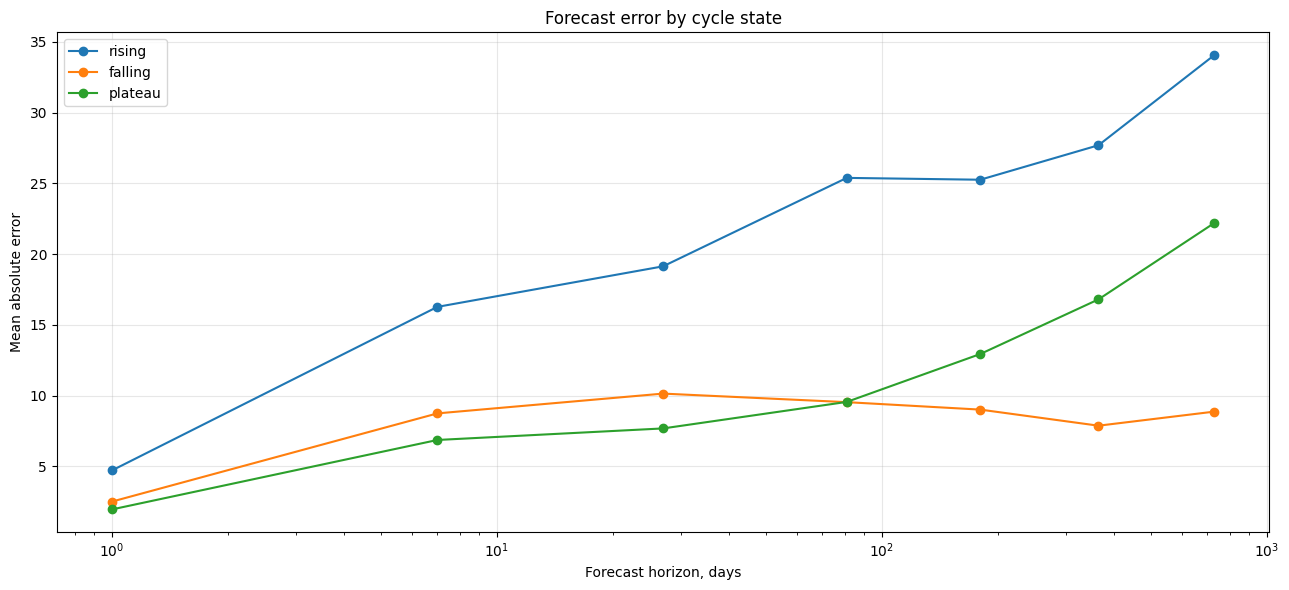

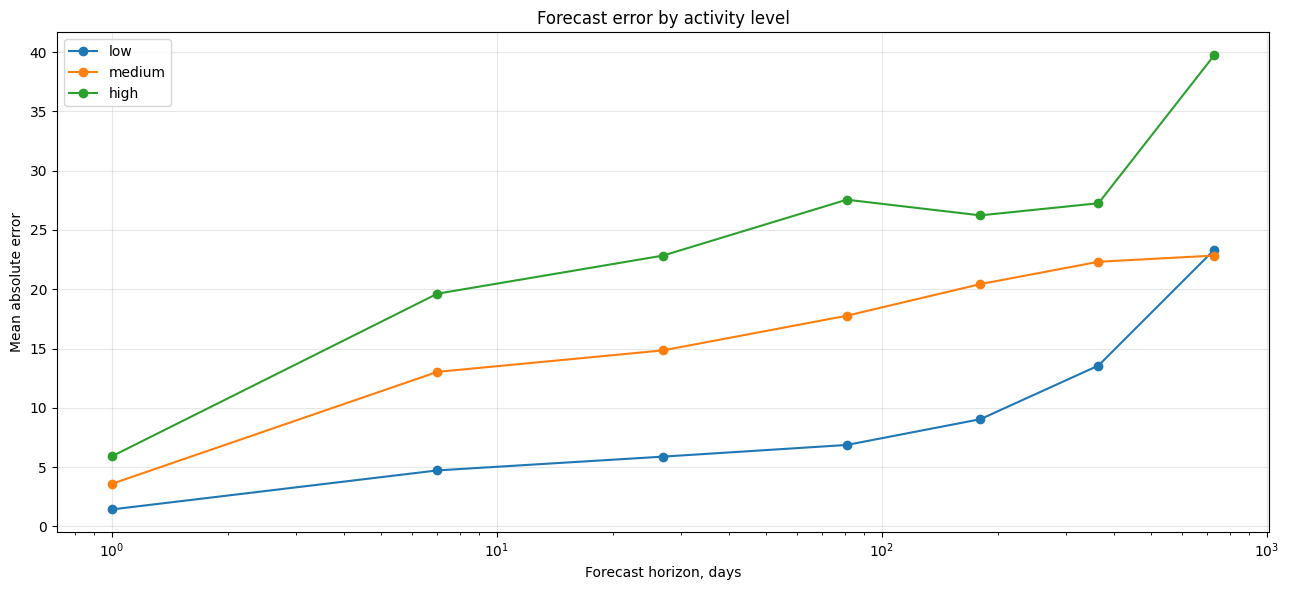

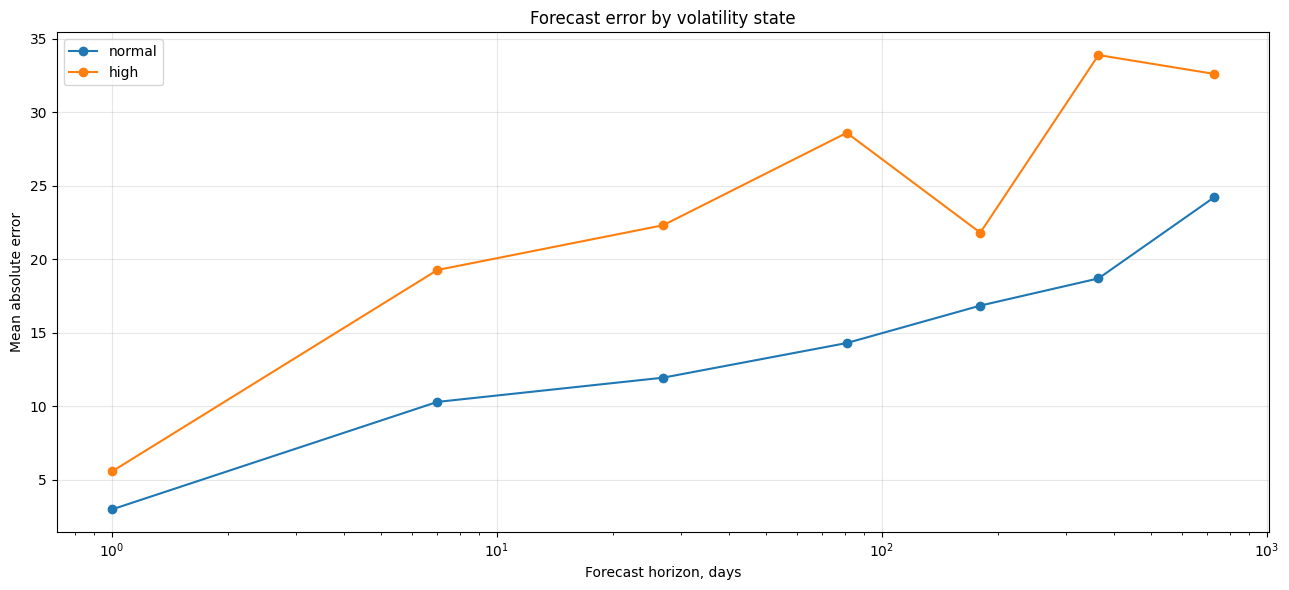

In [45]:
# графики ошибки по режимам

def plot_error_by_group(summary_df, group_col, title, filename, order):
    plt.figure(figsize=(13, 6))

    for value in order:
        subset = summary_df[summary_df[group_col] == value]

        if len(subset) == 0:
            continue

        plt.plot(
            subset["horizon_days"],
            subset["MAE"],
            marker="o",
            label=value
        )

    plt.title(title)
    plt.xlabel("Forecast horizon, days")
    plt.ylabel("Mean absolute error")
    plt.xscale("log")
    plt.grid(True, alpha=0.3)
    plt.legend()

    plt.tight_layout()
    plt.savefig(plots_dir / filename, dpi=150)
    plt.show()


plot_error_by_group(
    ml5_error_by_cycle_state,
    group_col="cycle_state",
    title="Forecast error by cycle state",
    filename="31_ml5_error_by_cycle_state.png",
    order=["rising", "falling", "plateau"]
)


plot_error_by_group(
    ml5_error_by_activity_level,
    group_col="activity_level",
    title="Forecast error by activity level",
    filename="32_ml5_error_by_activity_level.png",
    order=["low", "medium", "high"]
)


plot_error_by_group(
    ml5_error_by_volatility_state,
    group_col="volatility_state",
    title="Forecast error by volatility state",
    filename="33_ml5_error_by_volatility_state.png",
    order=["normal", "high"]
)

In [46]:
import zipfile
from pathlib import Path
from google.colab import files

root = Path("/content")
zip_path = Path("/tmp/f107_project_all.zip")

skip_dirs = {"sample_data", ".config", "__pycache__", ".ipynb_checkpoints"}

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
    for path in root.rglob("*"):
        if path.is_file():
            if any(part in skip_dirs for part in path.parts):
                continue
            z.write(path, path.relative_to(root))

files.download(str(zip_path))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>